In [1]:
using CairoMakie
using CSV
using DataFrames

function scatter_with_line!(ax, x, y; color, label)
    lines!(ax, x, y; color=color, linewidth=2)
    scatter!(ax, x, y; color=color, marker=:circle, 
             markersize=8, label=label)
end

# Load the CSV file
seed = 1  # Change this to load different seed files
df = CSV.read("dda_constraint_iswap_seed_$seed.csv", DataFrame)

# Create the figure
fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
)

# Get wong colors (same as in original code)
colors = Makie.wong_colors()
colors[1] = RGBf(0, 0, 0) 
# Plot the three lines with scatter points
scatter_with_line!(ax, df.ä_vals, df.def_avg_vec; color=colors[1], label="Default")
scatter_with_line!(ax, df.ä_vals, df.var_avg_vec; color=colors[2], label="Variational")
scatter_with_line!(ax, df.ä_vals, df.uni_avg_vec; color=colors[4], label="Universal")

# Add legend
axislegend(ax; position = :rt)

# Display the figure
display(fig)

# Optionally save it
save("dda_constraint_iswap_seed_$(seed)_plot.png", fig)

ArgumentError: ArgumentError: Package CairoMakie not found in current path.
- Run `import Pkg; Pkg.add("CairoMakie")` to install the CairoMakie package.

In [2]:
using Pkg
Pkg.activate("..")

  Activating project at `~/notebooks/src`


Reading data from 6 seed files...
Calculating statistics...


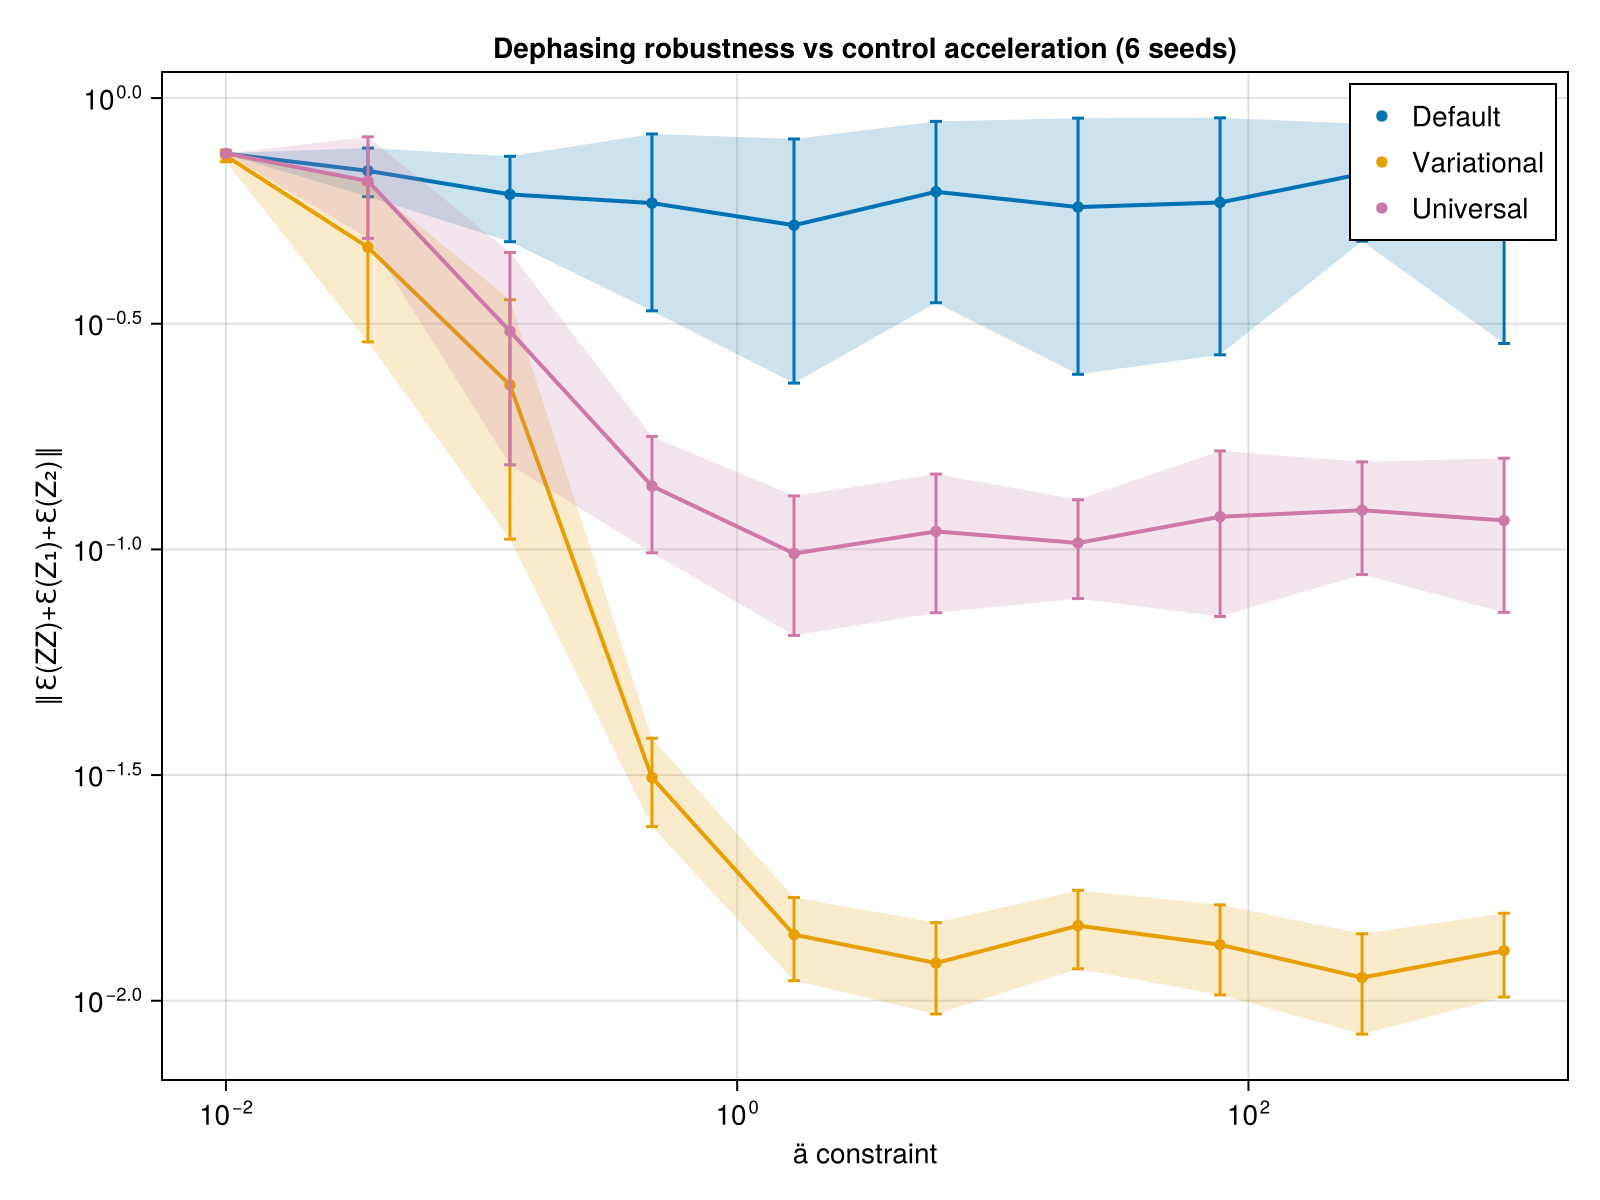

In [3]:
using CairoMakie
using CSV
using DataFrames
using Statistics

function scatter_with_line_and_error!(ax, x, y, yerr; color, label)
    # Plot error band
    band!(ax, x, y .- yerr, y .+ yerr; color=(color, 0.2))
    # Plot line
    lines!(ax, x, y; color=color, linewidth=2)
    # Plot scatter points
    scatter!(ax, x, y; color=color, marker=:circle, 
             markersize=8, label=label)
    # Add error bars
    errorbars!(ax, x, y, yerr; color=color, linewidth=1.5, whiskerwidth=6)
end

function aggregate_seed_data(num_seeds::Int)
    def_data = []
    var_data = []
    uni_data = []
    ä_vals = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            
            if ä_vals === nothing
                ä_vals = df.ä_vals
            end
            
            push!(def_data, df.def_avg_vec)
            push!(var_data, df.var_avg_vec)
            push!(uni_data, df.uni_avg_vec)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return def_data, var_data, uni_data, ä_vals
end

function calculate_stats(data_list)
    # Convert list of vectors to matrix (ä_vals × seeds)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds = [std(data_matrix[i, :]) for i in 1:n_points]
    
    return means, stds
end

# Number of seeds to average over
num_seeds = 6

println("Reading data from $num_seeds seed files...")
def_data, var_data, uni_data, ä_vals = aggregate_seed_data(num_seeds)

if isempty(def_data)
    error("No data found!")
end

println("Calculating statistics...")
def_means, def_stds = calculate_stats(def_data)
var_means, var_stds = calculate_stats(var_data)
uni_means, uni_stds = calculate_stats(uni_data)

# Create the figure
fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration ($num_seeds seeds)",
)

# Get wong colors (same as in original code)
colors = Makie.wong_colors()

# Plot the three lines with scatter points and error bars
scatter_with_line_and_error!(ax, ä_vals, def_means, def_stds; color=colors[1], label="Default")
scatter_with_line_and_error!(ax, ä_vals, var_means, var_stds; color=colors[2], label="Variational")
scatter_with_line_and_error!(ax, ä_vals, uni_means, uni_stds; color=colors[4], label="Universal")

# Add legend
axislegend(ax; position = :rt)

# Display the figure
display(fig)

# Optionally save it
save("dda_constraint_iswap_averaged_$(num_seeds)seeds.png", fig)

Reading data from 6 seed files...
Calculating statistics...


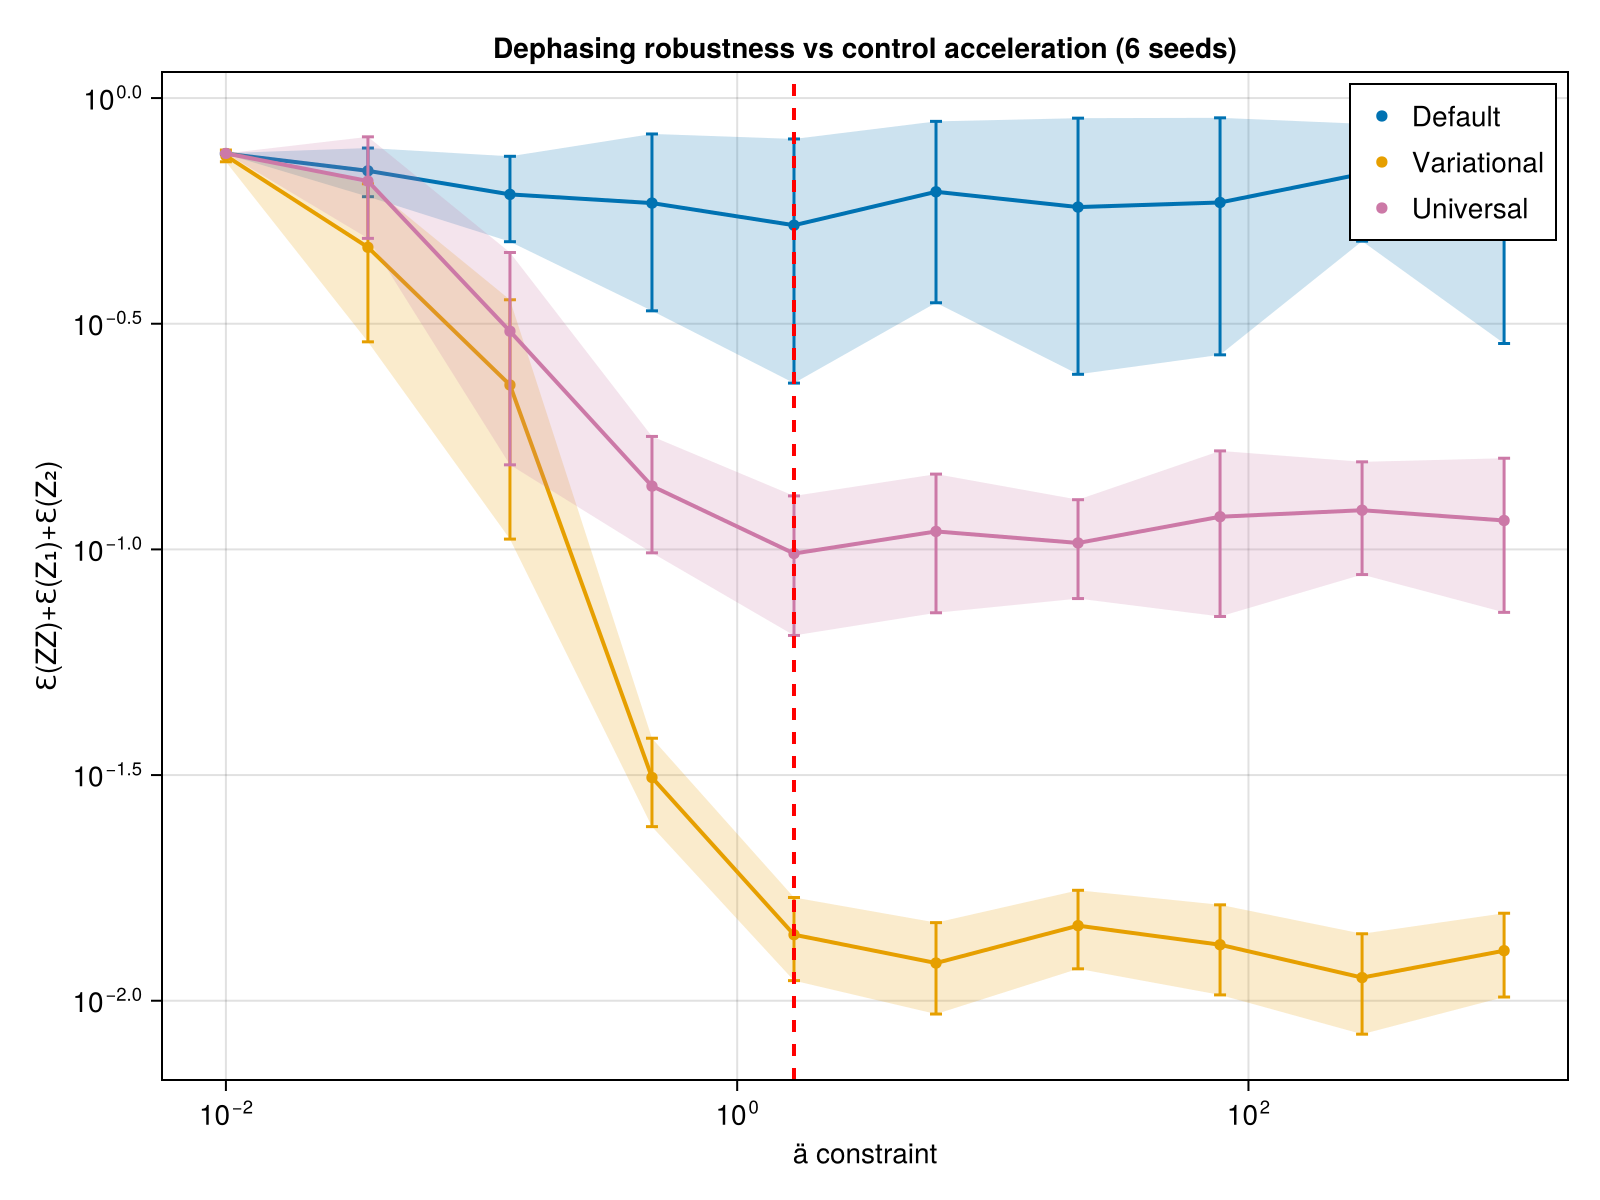

In [4]:
using CairoMakie
using CSV
using DataFrames
using Statistics

function scatter_with_line_and_error!(ax, x, y, yerr; color, label)
    # Plot error band
    band!(ax, x, y .- yerr, y .+ yerr; color=(color, 0.2))
    # Plot line
    lines!(ax, x, y; color=color, linewidth=2)
    # Plot scatter points
    scatter!(ax, x, y; color=color, marker=:circle, 
             markersize=8, label=label)
    # Add error bars
    errorbars!(ax, x, y, yerr; color=color, linewidth=1.5, whiskerwidth=6)
end

function aggregate_seed_data(num_seeds::Int)
    def_data = []
    var_data = []
    uni_data = []
    ä_vals = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            
            if ä_vals === nothing
                ä_vals = df.ä_vals
            end
            
            push!(def_data, df.def_avg_vec)
            push!(var_data, df.var_avg_vec)
            push!(uni_data, df.uni_avg_vec)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return def_data, var_data, uni_data, ä_vals
end

function calculate_stats(data_list)
    # Convert list of vectors to matrix (ä_vals × seeds)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds = [std(data_matrix[i, :]) for i in 1:n_points]
    
    return means, stds
end

# Number of seeds to average over
num_seeds = 6

println("Reading data from $num_seeds seed files...")
def_data, var_data, uni_data, ä_vals = aggregate_seed_data(num_seeds)

if isempty(def_data)
    error("No data found!")
end

println("Calculating statistics...")
def_means, def_stds = calculate_stats(def_data)
var_means, var_stds = calculate_stats(var_data)
uni_means, uni_stds = calculate_stats(uni_data)

# Create the figure
fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration ($num_seeds seeds)",
)

# Get wong colors (same as in original code)
colors = Makie.wong_colors()

# Plot the three lines with scatter points and error bars
scatter_with_line_and_error!(ax, ä_vals, def_means, def_stds; color=colors[1], label="Default")
scatter_with_line_and_error!(ax, ä_vals, var_means, var_stds; color=colors[2], label="Variational")
scatter_with_line_and_error!(ax, ä_vals, uni_means, uni_stds; color=colors[4], label="Universal")

# Add legend
axislegend(ax; position = :rt)

# Add vertical dashed red line at ä = 5
vlines!(ax, ä_vals[5]; color=:red, linestyle=:dash, linewidth=2)

# Display the figure
display(fig)

# Optionally save it
save("dda_constraint_iswap_averaged_$(num_seeds)seeds.png", fig)

Reading data from 6 seed files...
Calculating statistics...


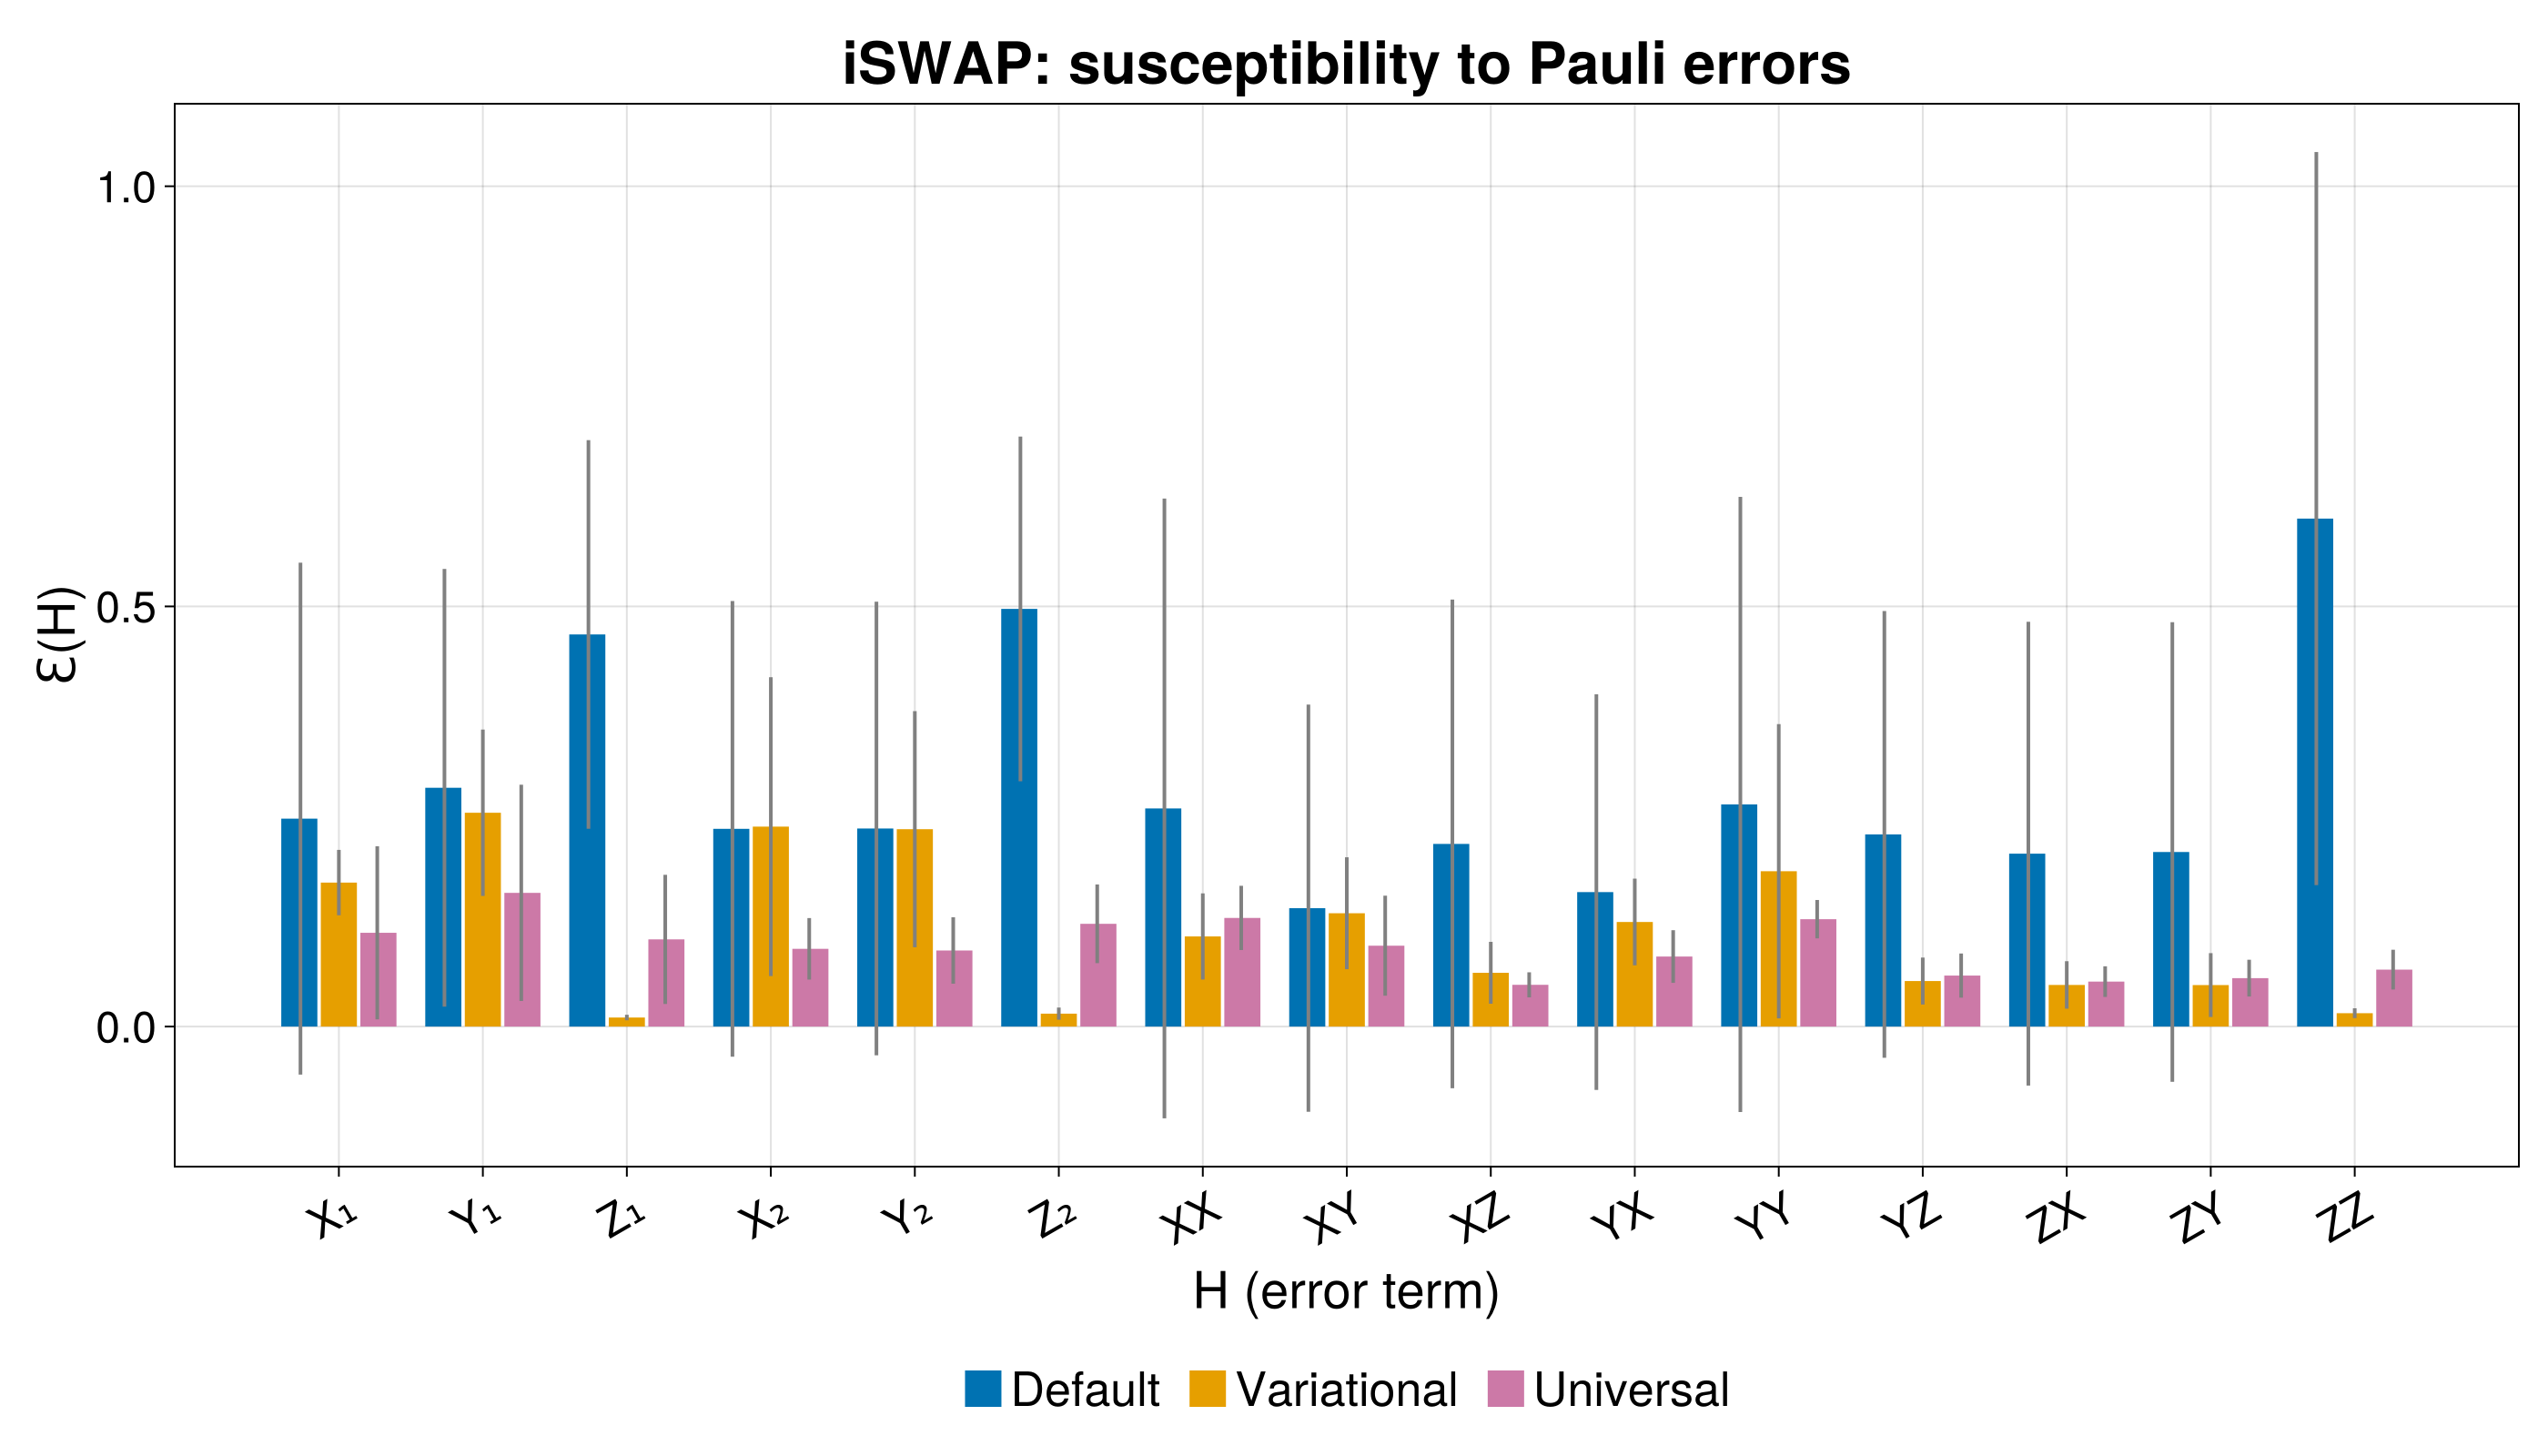

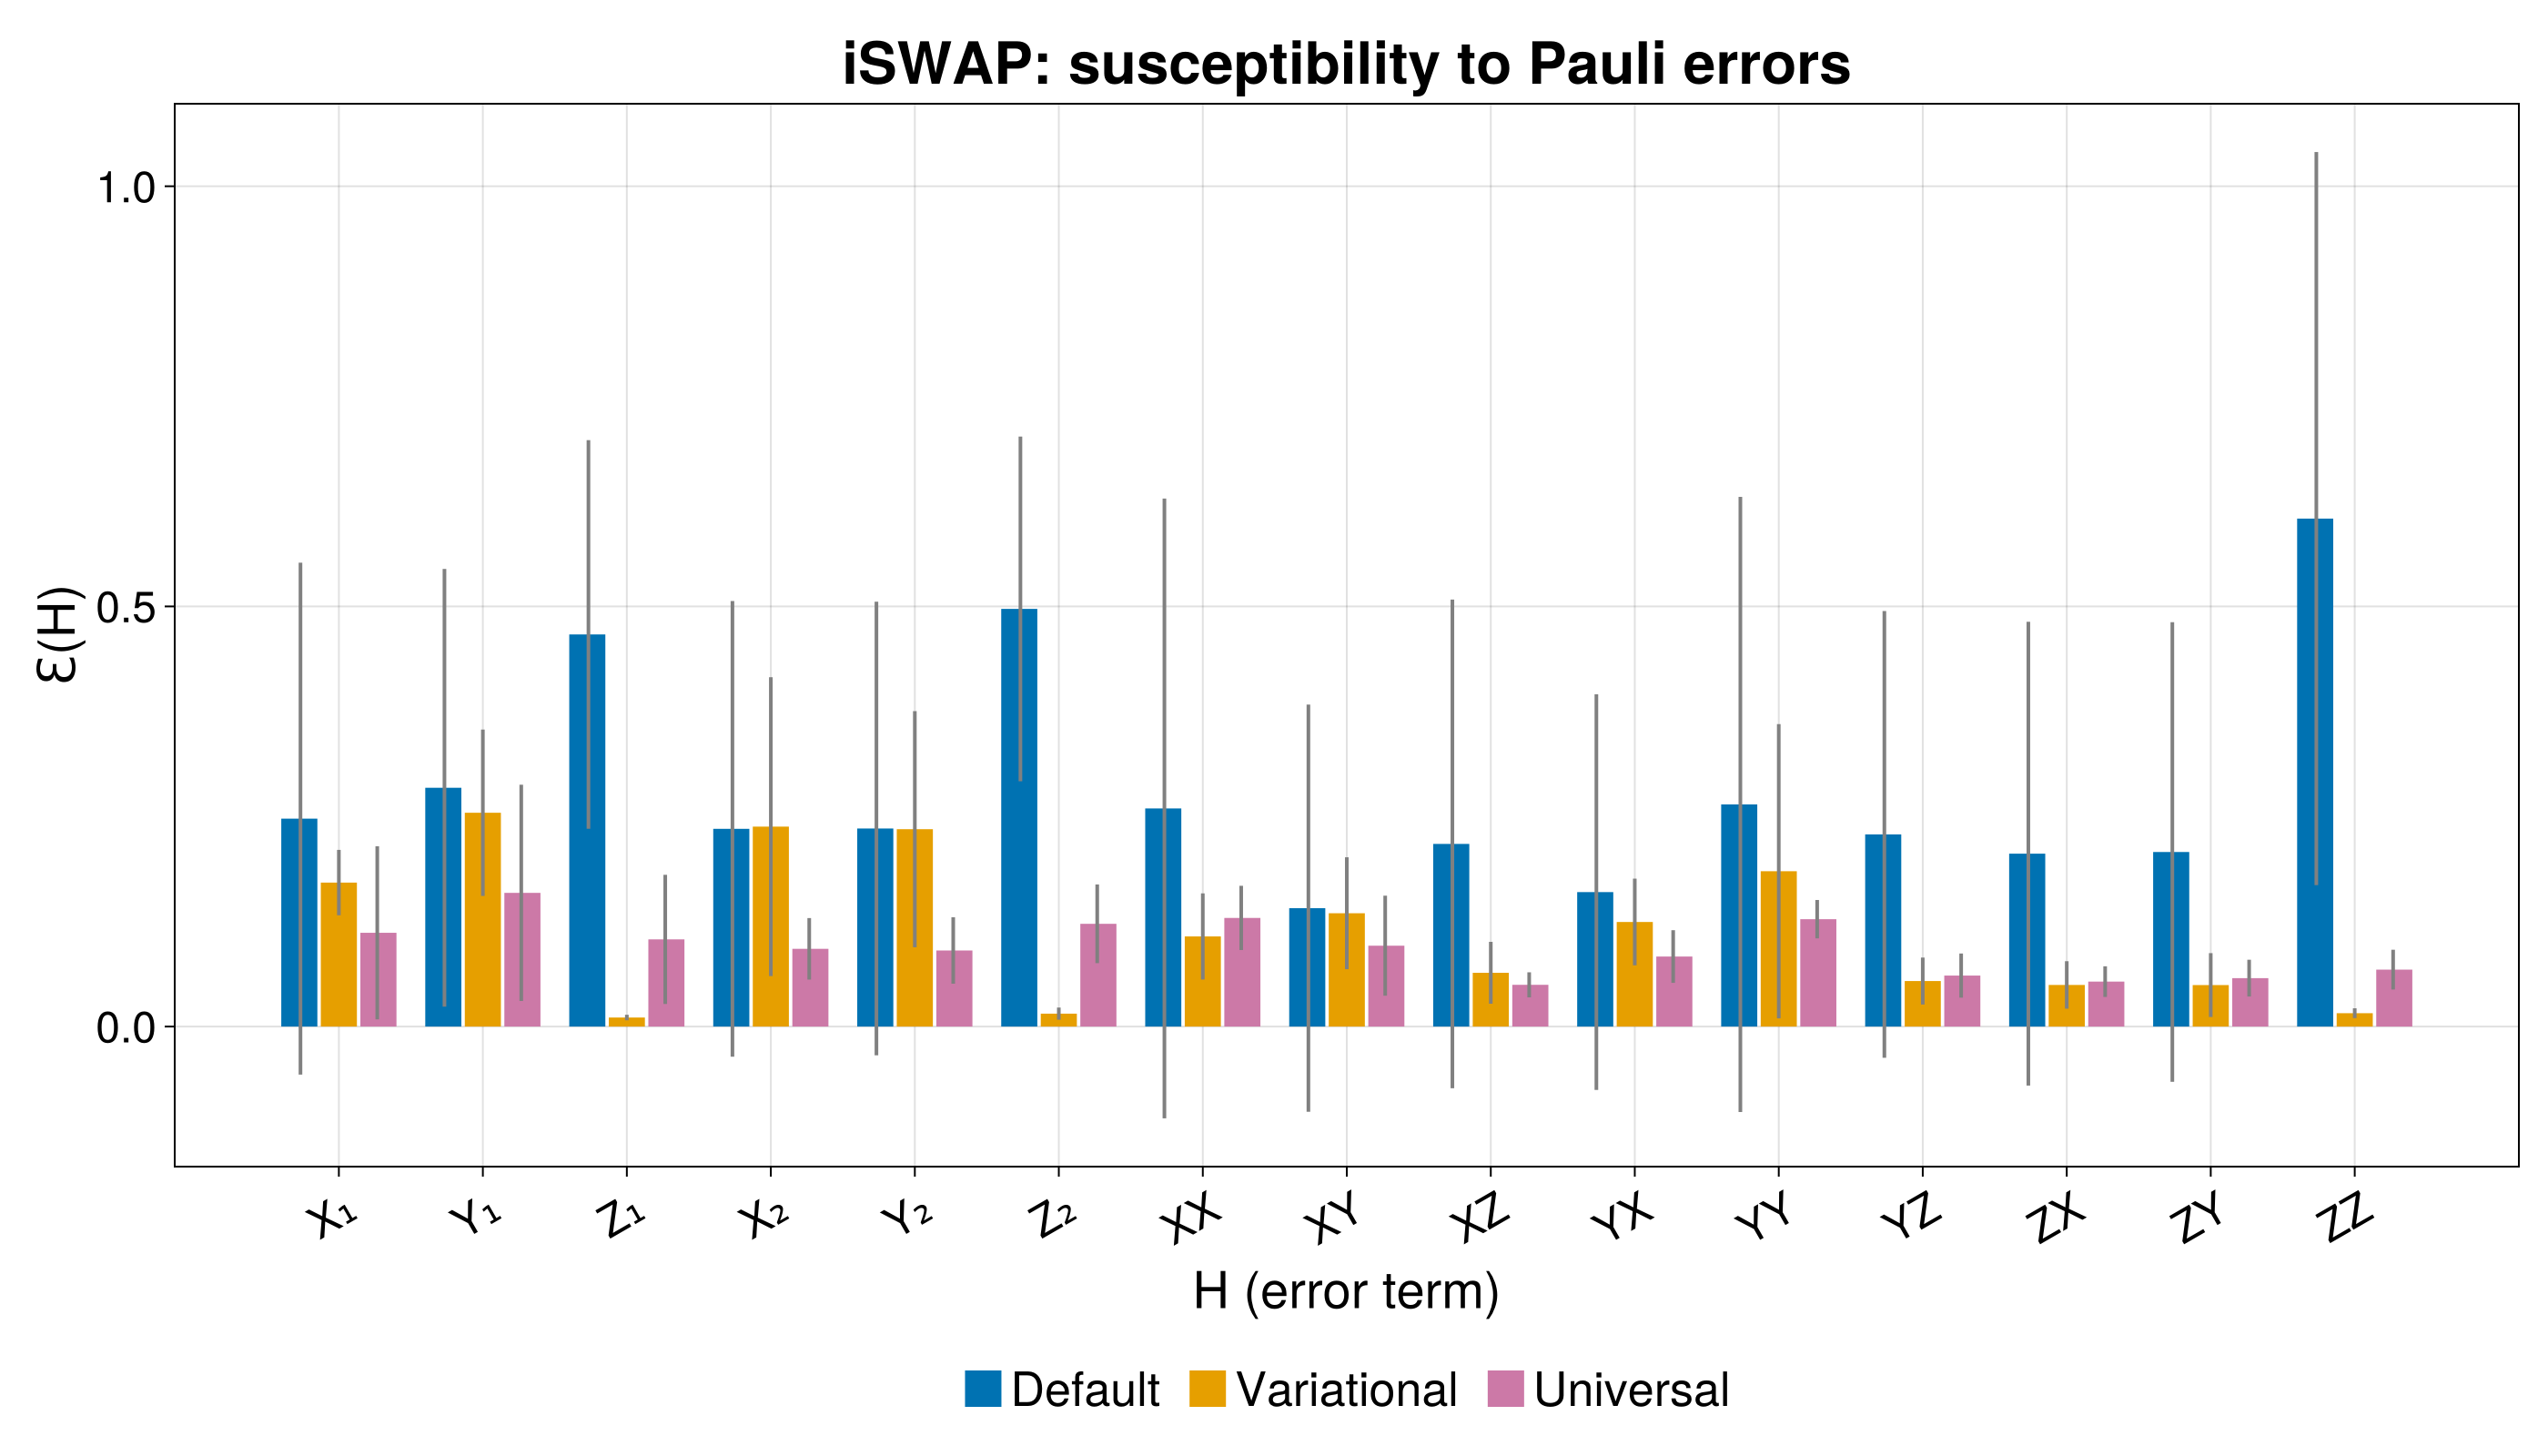

In [5]:
using DataFrames, CSV, CairoMakie, Statistics
CM = CairoMakie

function parse_vector_string(s::String)
    # Remove "Any" prefix, brackets, and split by comma
    s = strip(s)
    s = replace(s, r"^Any" => "")  # Remove "Any" at start
    s = replace(s, "[" => "")
    s = replace(s, "]" => "")
    # Split by comma and parse, filtering out empty strings
    parts = filter(!isempty, strip.(split(s, ",")))
    return parse.(Float64, parts)
end

function aggregate_seed_data(num_seeds::Int, index::Int)
    var_data = []
    def_data = []
    uni_data = []
    ä_val = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            
            if ä_val === nothing
                ä_val = df.ä_vals[index]
            end
            
            # Parse the full vectors for this index
            var_full = parse_vector_string(df.var_full_vec[index])
            def_full = parse_vector_string(df.def_full_vec[index])
            uni_full = parse_vector_string(df.uni_full_vec[index])
            
            push!(var_data, var_full)
            push!(def_data, def_full)
            push!(uni_data, uni_full)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return var_data, def_data, uni_data, ä_val
end

function calculate_stats(data_list)
    # Convert list of vectors to matrix (errors × seeds)
    data_matrix = hcat(data_list...)
    n_errors = size(data_matrix, 1)
    
    means = [mean(data_matrix[i, :]) for i in 1:n_errors]
    stds = [std(data_matrix[i, :]) for i in 1:n_errors]
    
    return means, stds
end

function create_bar_chart_for_index(num_seeds::Int, index::Int)
    # Aggregate data from all seeds
    println("Reading data from $num_seeds seed files...")
    var_data, def_data, uni_data, ä_val = aggregate_seed_data(num_seeds, index)
    
    if isempty(var_data)
        error("No data found!")
    end
    
    println("Calculating statistics...")
    var_means, var_stds = calculate_stats(var_data)
    def_means, def_stds = calculate_stats(def_data)
    uni_means, uni_stds = calculate_stats(uni_data)
    
    # Error labels (Pauli strings from your code)
    err_labels = ["X₁", "Y₁", "Z₁", "X₂", "Y₂", "Z₂", "XX", "XY", "XZ", "YX", "YY", "YZ", "ZX", "ZY", "ZZ"]
    
    methods = ["Default", "Variational", "Universal"]
    n_errors = length(err_labels)
    
    # Organize data for plotting
    y = collect(Iterators.flatten((def_means[i], var_means[i], uni_means[i]) for i in 1:n_errors))
    yerr = collect(Iterators.flatten((def_stds[i], var_stds[i], uni_stds[i]) for i in 1:n_errors))
    
    x = repeat(1:n_errors, inner=3)
    g = repeat(1:3, outer=n_errors)
    
    # Colors (matching your style)
    palette = Makie.wong_colors()
    series_colors = [palette[1], palette[2], palette[4]]  # Default, Variational, Universal
    barcolors = series_colors[g]
    
    # Create figure
    fig = CM.Figure(size=(1400, 800), fontsize=30)
    
    ax = CM.Axis(fig[1, 1];
        xticks = (1:n_errors, err_labels),
        xticklabelrotation = π/6,
        xlabel = "H (error term)",
        ylabel = "Ɛ(H)",
        title = "iSWAP: susceptibility to Pauli errors",
        xlabelsize = 28,
        ylabelsize = 28,
        titlesize = 32,
        xticklabelsize = 24,
        yticklabelsize = 24,
    )
    
    CM.barplot!(ax, x, y; dodge=g, color=barcolors, gap=0.2)
    
    # Add error bars with manual dodge offsets
    dodge_width = 0.8
    n_dodge = 3
    width = dodge_width / n_dodge
    error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in 1:length(x)]
    CM.errorbars!(ax, error_x, y, yerr; color=:gray, linewidth=2)
    
    # Add legend
    CM.Legend(fig[2, 1],
        [CM.PolyElement(color=series_colors[i]) for i in 1:3],
        methods;
        orientation=:horizontal,
        labelsize=26,
        framevisible=false
    )
    
    display(fig)
    #save("pauli_errors_averaged_$(num_seeds)seeds_index$(index)_a$(round(ä_val, sigdigits=3)).png", fig)
    
    return fig
end

# Example usage:
num_seeds = 6  # Number of seed files to average over (1-5)
index = 5    # Which ä_vals index to plot (1-10)

fig = create_bar_chart_for_index(num_seeds, index)

In [6]:
using DataFrames, CSV, CairoMakie, Statistics
CM = CairoMakie

# Function to read and aggregate data from multiple seed files
function aggregate_seed_data(num_seeds::Int, file_pattern::String)
    all_data = Dict{String, Vector{Vector{Float64}}}()
    err_labels = nothing
    for seed in 1:num_seeds
        filename = replace(file_pattern, "SEED" => string(seed))
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        try
            df = CSV.read(filename, DataFrame)
            if err_labels === nothing
                err_labels = df.Error
            end
            for method in ["Default", "Variational", "Toggling", "Universal"]
                if haskey(all_data, method)
                    push!(all_data[method], df[!, method])
                else
                    all_data[method] = [df[!, method]]
                end
            end
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    return all_data, err_labels
end

function calculate_stats(all_data, err_labels)
    methods = ["Default", "Variational", "Toggling", "Universal"]
    n_errors = length(err_labels)
    means = Dict{String, Vector{Float64}}()
    stds  = Dict{String, Vector{Float64}}()
    for method in methods
        if haskey(all_data, method)
            data_matrix = hcat(all_data[method]...)
            means[method] = [mean(data_matrix[i, :]) for i in 1:n_errors]
            stds[method]  = [std(data_matrix[i, :]) for i in 1:n_errors]
        else
            means[method] = zeros(n_errors)
            stds[method]  = zeros(n_errors)
        end
    end
    return means, stds
end

function create_bar_subplot!(fig, row, col, means, stds, err_labels, title_text, num_seeds)
    methods = ["Default", "Variational", "Toggling", "Universal"]
    n = length(err_labels)

    y = collect(Iterators.flatten((means[m][i] for m in methods) for i in 1:n))
    yerr = collect(Iterators.flatten((stds[m][i] for m in methods) for i in 1:n))

    x = repeat(1:n, inner=4)
    g = repeat(1:4, outer=n)

    palette = Makie.wong_colors()
    series_colors = palette[1:4]
    barcolors = series_colors[g]

    ax = CM.Axis(fig[row, col];
        xticks = (1:n, err_labels),
        xticklabelrotation = π/6,
        xlabel = "Error operator",
        ylabel = "‖E‖",
        title = title_text,
        xlabelsize = 34,
        ylabelsize = 34,
        titlesize = 38,
        xticklabelsize = 28,
        yticklabelsize = 28,
    )

    CM.barplot!(ax, x, y; dodge=g, color=barcolors, gap=0.25)

    # manual dodge offsets for errorbars
    dodge_width = 0.8
    n_dodge = 4
    width = dodge_width / n_dodge
    error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in 1:length(x)]
    CM.errorbars!(ax, error_x, y, yerr; color=:gray, linewidth=2)

    return ax, series_colors
end

function create_stacked_bar_chart(means1, stds1, err_labels1, means2, stds2, err_labels2, num_seeds)
    methods = ["Default", "Variational", "Toggling", "Universal"]
    fig = CM.Figure(resolution=(1600, 1600), fontsize=30, padding=25)

    ax1, series_colors = create_bar_subplot!(
        fig, 1, 1, means1, stds1, err_labels1,
        "Average terminal norms (ZZ robustness target, $num_seeds seeds)", num_seeds)

    ax2, _ = create_bar_subplot!(
        fig, 2, 1, means2, stds2, err_labels2,
        "Average terminal norms (Z1, Z2, ZZ robustness target, $num_seeds seeds)", num_seeds)

    CM.Legend(fig[3, 1],
        [CM.PolyElement(color=series_colors[i]) for i in 1:4],
        methods;
        orientation=:horizontal,
        labelsize=32,
    )

    return fig
end

# Parameters
num_seeds = 10
file_pattern_zz = "terminal_spacecurve_norms_ZZ_T30_seedSEED.csv"
file_pattern_z1z2zz = "terminal_spacecurve_norms_Z1_Z2_ZZ_T30_seedSEED.csv"

println("Reading ZZ objective data from seed files...")
all_data_zz, err_labels_zz = aggregate_seed_data(num_seeds, file_pattern_zz)

println("Reading Z1_Z2_ZZ objective data from seed files...")
all_data_z1z2zz, err_labels_z1z2zz = aggregate_seed_data(num_seeds, file_pattern_z1z2zz)

if err_labels_zz !== nothing && err_labels_z1z2zz !== nothing
    println("Calculating statistics...")
    means_zz, stds_zz = calculate_stats(all_data_zz, err_labels_zz)
    means_z1z2zz, stds_z1z2zz = calculate_stats(all_data_z1z2zz, err_labels_z1z2zz)

    println("\nCreating stacked bar chart...")
    fig = create_stacked_bar_chart(
        means_zz, stds_zz, err_labels_zz,
        means_z1z2zz, stds_z1z2zz, err_labels_z1z2zz,
        num_seeds
    )

    # Panel tags (a), (b)
    CM.Label(fig[1, 1, CM.TopLeft()], "(a)"; fontsize=50, padding=(15,0,0,0), tellwidth=false)
    CM.Label(fig[2, 1, CM.TopLeft()], "(b)"; fontsize=50, padding=(15,0,0,0), tellwidth=false)

    display(fig)
    save("iswap_paper_fig.png", fig; px_per_unit=3)
end

Reading ZZ objective data from seed files...
Reading Z1_Z2_ZZ objective data from seed files...


Reading average data from 50 seed files...
Calculating statistics for average plot...
Reading full data for bar chart (index=5)...
Calculating statistics for bar chart...

Figure saved: combined_iswap_figure_50seeds.svg
Parameters used: num_seeds=50, index=5 (ä=1.67)


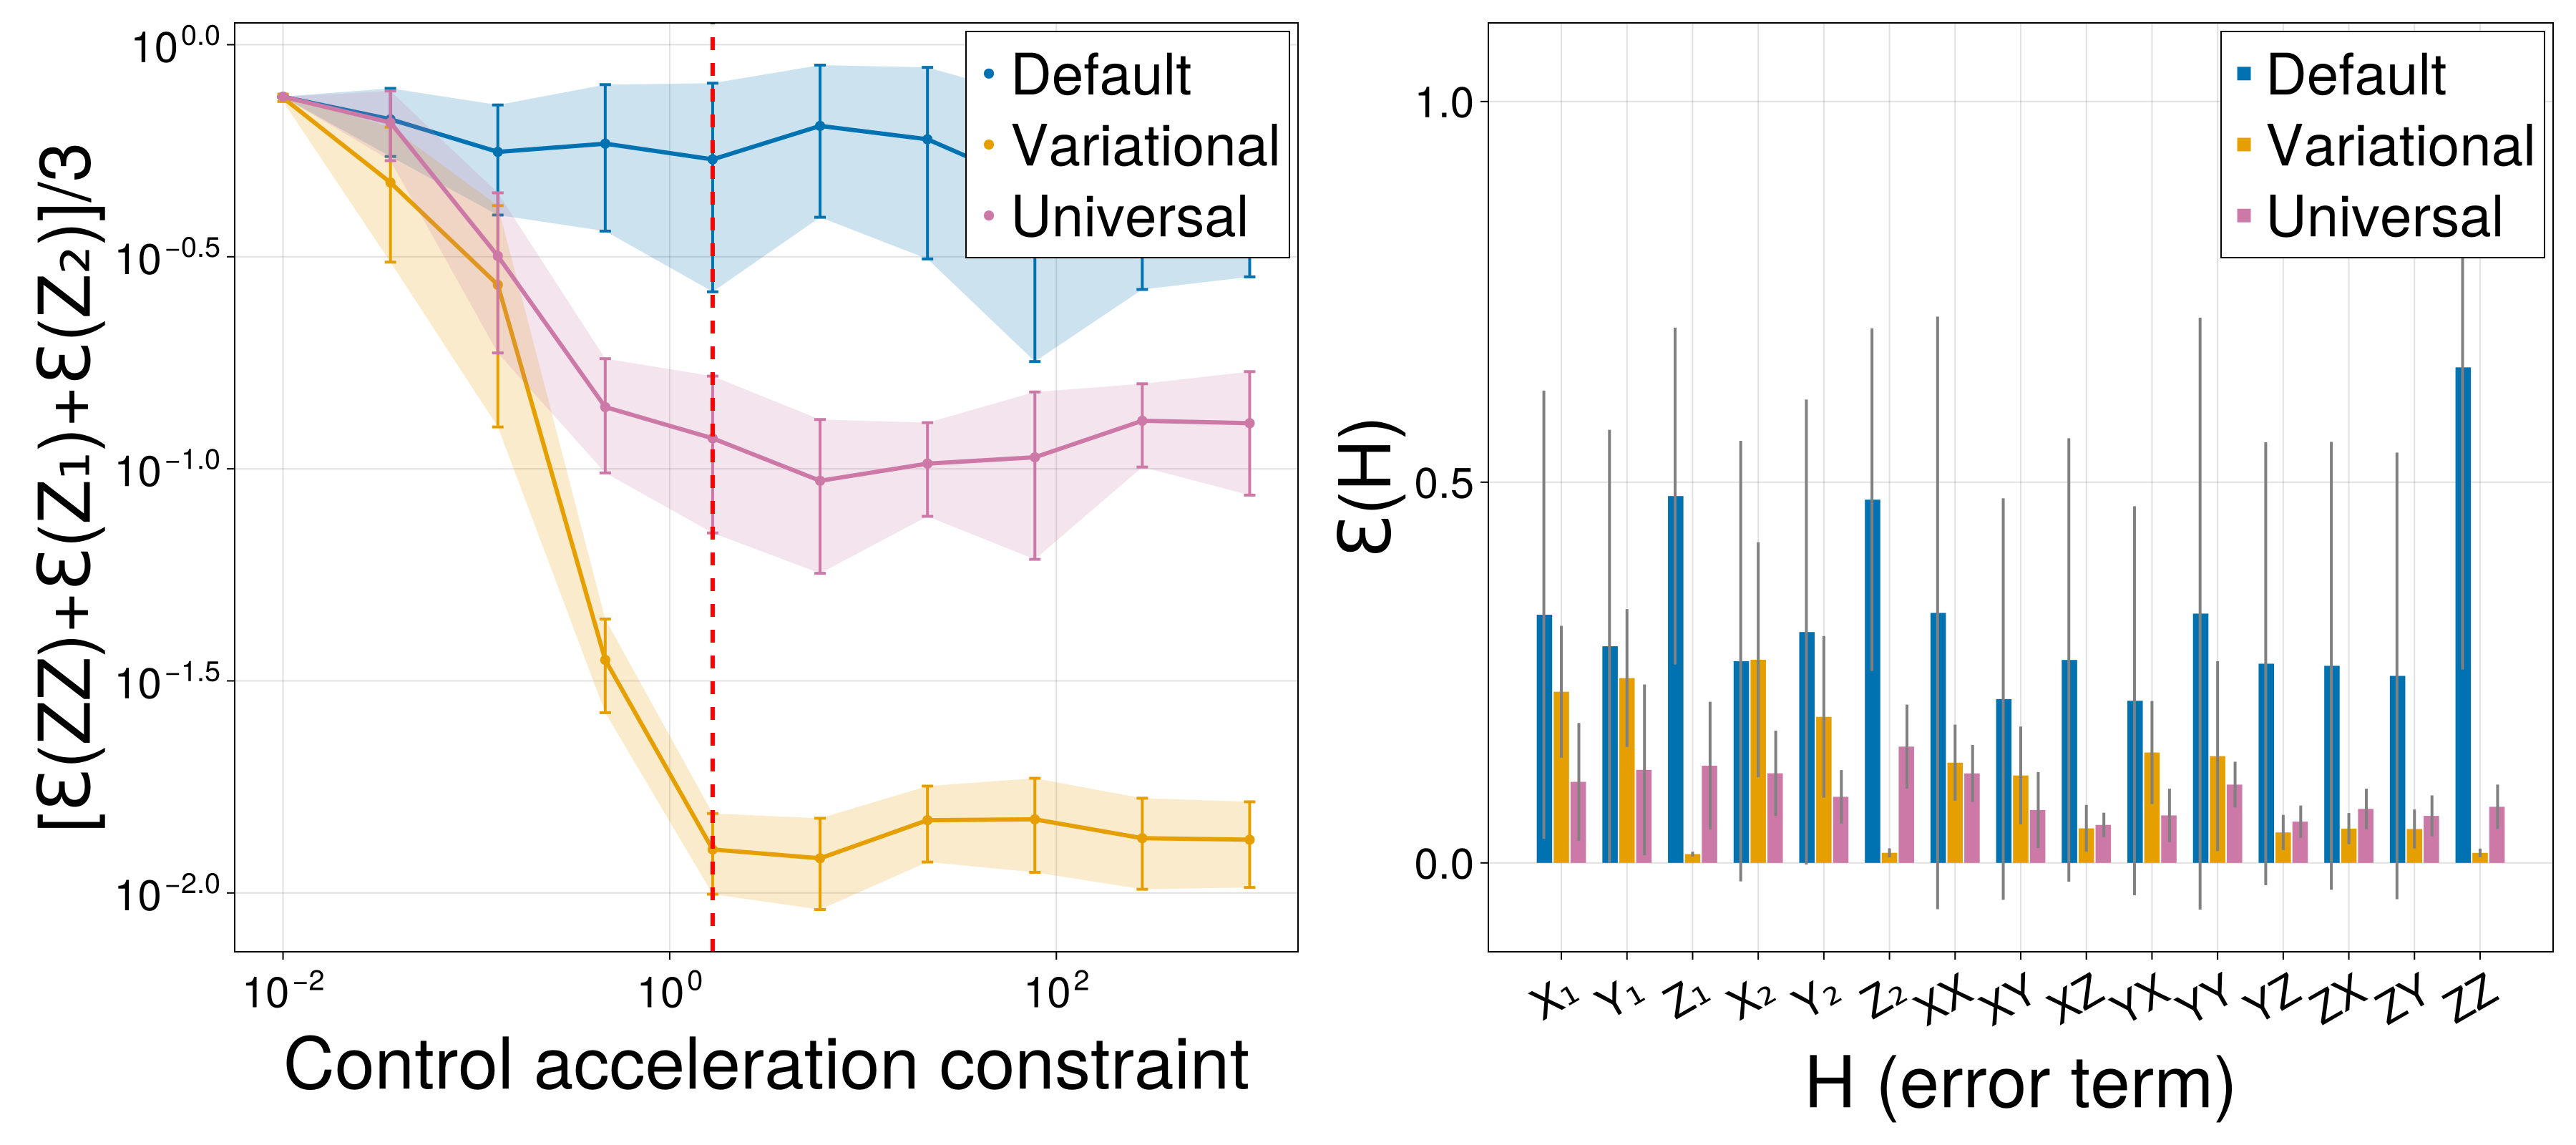

In [7]:
using CairoMakie
using CSV
using DataFrames
using Statistics

# ============= PARAMETERS TO CHANGE =============
num_seeds = 50
index = 5  # Which ä_vals index for bar chart
# ================================================

function parse_vector_string(s::String)
    s = strip(s)
    s = replace(s, r"^Any" => "")
    s = replace(s, "[" => "")
    s = replace(s, "]" => "")
    parts = filter(!isempty, strip.(split(s, ",")))
    return parse.(Float64, parts)
end

function scatter_with_line_and_error!(ax, x, y, yerr; color, label)
    band!(ax, x, y .- yerr, y .+ yerr; color=(color, 0.2))
    lines!(ax, x, y; color=color, linewidth=3)
    scatter!(ax, x, y; color=color, marker=:circle, markersize=10, label=label)
    errorbars!(ax, x, y, yerr; color=color, linewidth=2, whiskerwidth=8)
end

function aggregate_seed_data_avg(num_seeds::Int)
    def_data = []
    var_data = []
    uni_data = []
    ä_vals = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            if ä_vals === nothing
                ä_vals = df.ä_vals
            end
            push!(def_data, df.def_avg_vec)
            push!(var_data, df.var_avg_vec)
            push!(uni_data, df.uni_avg_vec)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return def_data, var_data, uni_data, ä_vals
end

function aggregate_seed_data_full(num_seeds::Int, index::Int)
    var_data = []
    def_data = []
    uni_data = []
    ä_val = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            if ä_val === nothing
                ä_val = df.ä_vals[index]
            end
            var_full = parse_vector_string(df.var_full_vec[index])
            def_full = parse_vector_string(df.def_full_vec[index])
            uni_full = parse_vector_string(df.uni_full_vec[index])
            
            push!(var_data, var_full)
            push!(def_data, def_full)
            push!(uni_data, uni_full)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return var_data, def_data, uni_data, ä_val
end

function calculate_stats(data_list)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds = [std(data_matrix[i, :]) for i in 1:n_points]
    return means, stds
end

# Read data for both plots
println("Reading average data from $num_seeds seed files...")
def_data, var_data, uni_data, ä_vals = aggregate_seed_data_avg(num_seeds)

if isempty(def_data)
    error("No data found!")
end

println("Calculating statistics for average plot...")
def_means, def_stds = calculate_stats(def_data)
var_means, var_stds = calculate_stats(var_data)
uni_means, uni_stds = calculate_stats(uni_data)

println("Reading full data for bar chart (index=$index)...")
var_data_full, def_data_full, uni_data_full, ä_val = aggregate_seed_data_full(num_seeds, index)

println("Calculating statistics for bar chart...")
var_means_full, var_stds_full = calculate_stats(var_data_full)
def_means_full, def_stds_full = calculate_stats(def_data_full)
uni_means_full, uni_stds_full = calculate_stats(uni_data_full)

# Create figure with two subplots
fig = Figure(size=(1800, 800), fontsize=40)

# Colors
colors = Makie.wong_colors()
series_colors = [colors[1], colors[2], colors[4]]

# LEFT PLOT: Line plot with error bars
ax1 = Axis(fig[1, 1];
    xlabel = "Control acceleration constraint",
    ylabel = "[Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)]/3",
    xscale = log10,
    yscale = log10,
    # title = "Dephasing robustness vs control acceleration",
    xlabelsize = 50,
    ylabelsize = 50,
    titlesize = 36,
    xticklabelsize = 30,
    yticklabelsize = 30,
)

scatter_with_line_and_error!(ax1, ä_vals, def_means, def_stds; color=colors[1], label="Default")
scatter_with_line_and_error!(ax1, ä_vals, var_means, var_stds; color=colors[2], label="Variational")
scatter_with_line_and_error!(ax1, ä_vals, uni_means, uni_stds; color=colors[4], label="Universal")

vlines!(ax1, ä_vals[index]; color=:red, linestyle=:dash, linewidth=3)

axislegend(ax1; position=:rt, labelsize=40)

# RIGHT PLOT: Bar chart
err_labels = ["X₁", "Y₁", "Z₁", "X₂", "Y₂", "Z₂", "XX", "XY", "XZ", "YX", "YY", "YZ", "ZX", "ZY", "ZZ"]
n_errors = length(err_labels)

y = collect(Iterators.flatten((def_means_full[i], var_means_full[i], uni_means_full[i]) for i in 1:n_errors))
yerr = collect(Iterators.flatten((def_stds_full[i], var_stds_full[i], uni_stds_full[i]) for i in 1:n_errors))

x = repeat(1:n_errors, inner=3)
g = repeat(1:3, outer=n_errors)
barcolors = series_colors[g]

ax2 = Axis(fig[1, 2];
    xticks = (1:n_errors, err_labels),
    xticklabelrotation = π/6,
    xlabel = "H (error term)",
    ylabel = "Ɛ(H)",
    # title = "Susceptibility to Pauli errors",
    xlabelsize = 50,
    ylabelsize = 50,
    titlesize = 36,
    xticklabelsize = 30,
    yticklabelsize = 30,
)

barplot!(ax2, x, y; dodge=g, color=barcolors, gap=0.25)

dodge_width = 0.8
n_dodge = 3
width = dodge_width / n_dodge
error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in 1:length(x)]
errorbars!(ax2, error_x, y, yerr; color=:gray, linewidth=2)

# Create invisible scatter plots with square markers for legend
scatter!(ax2, [NaN], [NaN]; color=series_colors[1], marker=:rect, markersize=15, label="Default")
scatter!(ax2, [NaN], [NaN]; color=series_colors[2], marker=:rect, markersize=15, label="Variational")
scatter!(ax2, [NaN], [NaN]; color=series_colors[3], marker=:rect, markersize=15, label="Universal")

# Add legend to top right of ax2
axislegend(ax2; position=:rt, labelsize=40)

# Add panel labels
# Label(fig[1, 1, TopLeft()], "(a)", fontsize=42, padding=(15, 0, 15, 0), tellwidth=false, tellheight=false)
# Label(fig[1, 2, TopLeft()], "(b)", fontsize=42, padding=(15, 0, 15, 0), tellwidth=false, tellheight=false)

display(fig)
save("iswap_paper_fig.svg", fig; px_per_unit=2)

println("\nFigure saved: combined_iswap_figure_$(num_seeds)seeds.svg")
println("Parameters used: num_seeds=$num_seeds, index=$index (ä=$(round(ä_val, sigdigits=3)))")

In [8]:
using MathTeXEngine

latex_serif_theme = Theme(
    fontsize = 40,
    fonts = (; 
        regular = texfont(:text), 
        bold = texfont(:bold), 
        italic = texfont(:italic), 
        bold_italic = texfont(:bolditalic),
        ticks = "TeX Gyre Heros Makie"
    ),
    Axis = (; 
        xticklabelsize=30,
        yticklabelsize=30,
        xgridvisible=false
    )
)

set_theme!(latex_serif_theme)

In [9]:
import Pkg; Pkg.add("MathTeXEngine")

   Resolving package versions...
  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651


  Activating project at `~/notebooks/src`
┌ Info: Reading average data from 50 seed files...
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:58
┌ Info: Missing dda_constraint_iswap_T50_seed_14.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:31
┌ Info: Missing dda_constraint_iswap_T50_seed_15.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:31
┌ Info: Missing dda_constraint_iswap_T50_seed_16.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:31
┌ Info: Missing dda_constraint_iswap_T50_seed_17.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlb

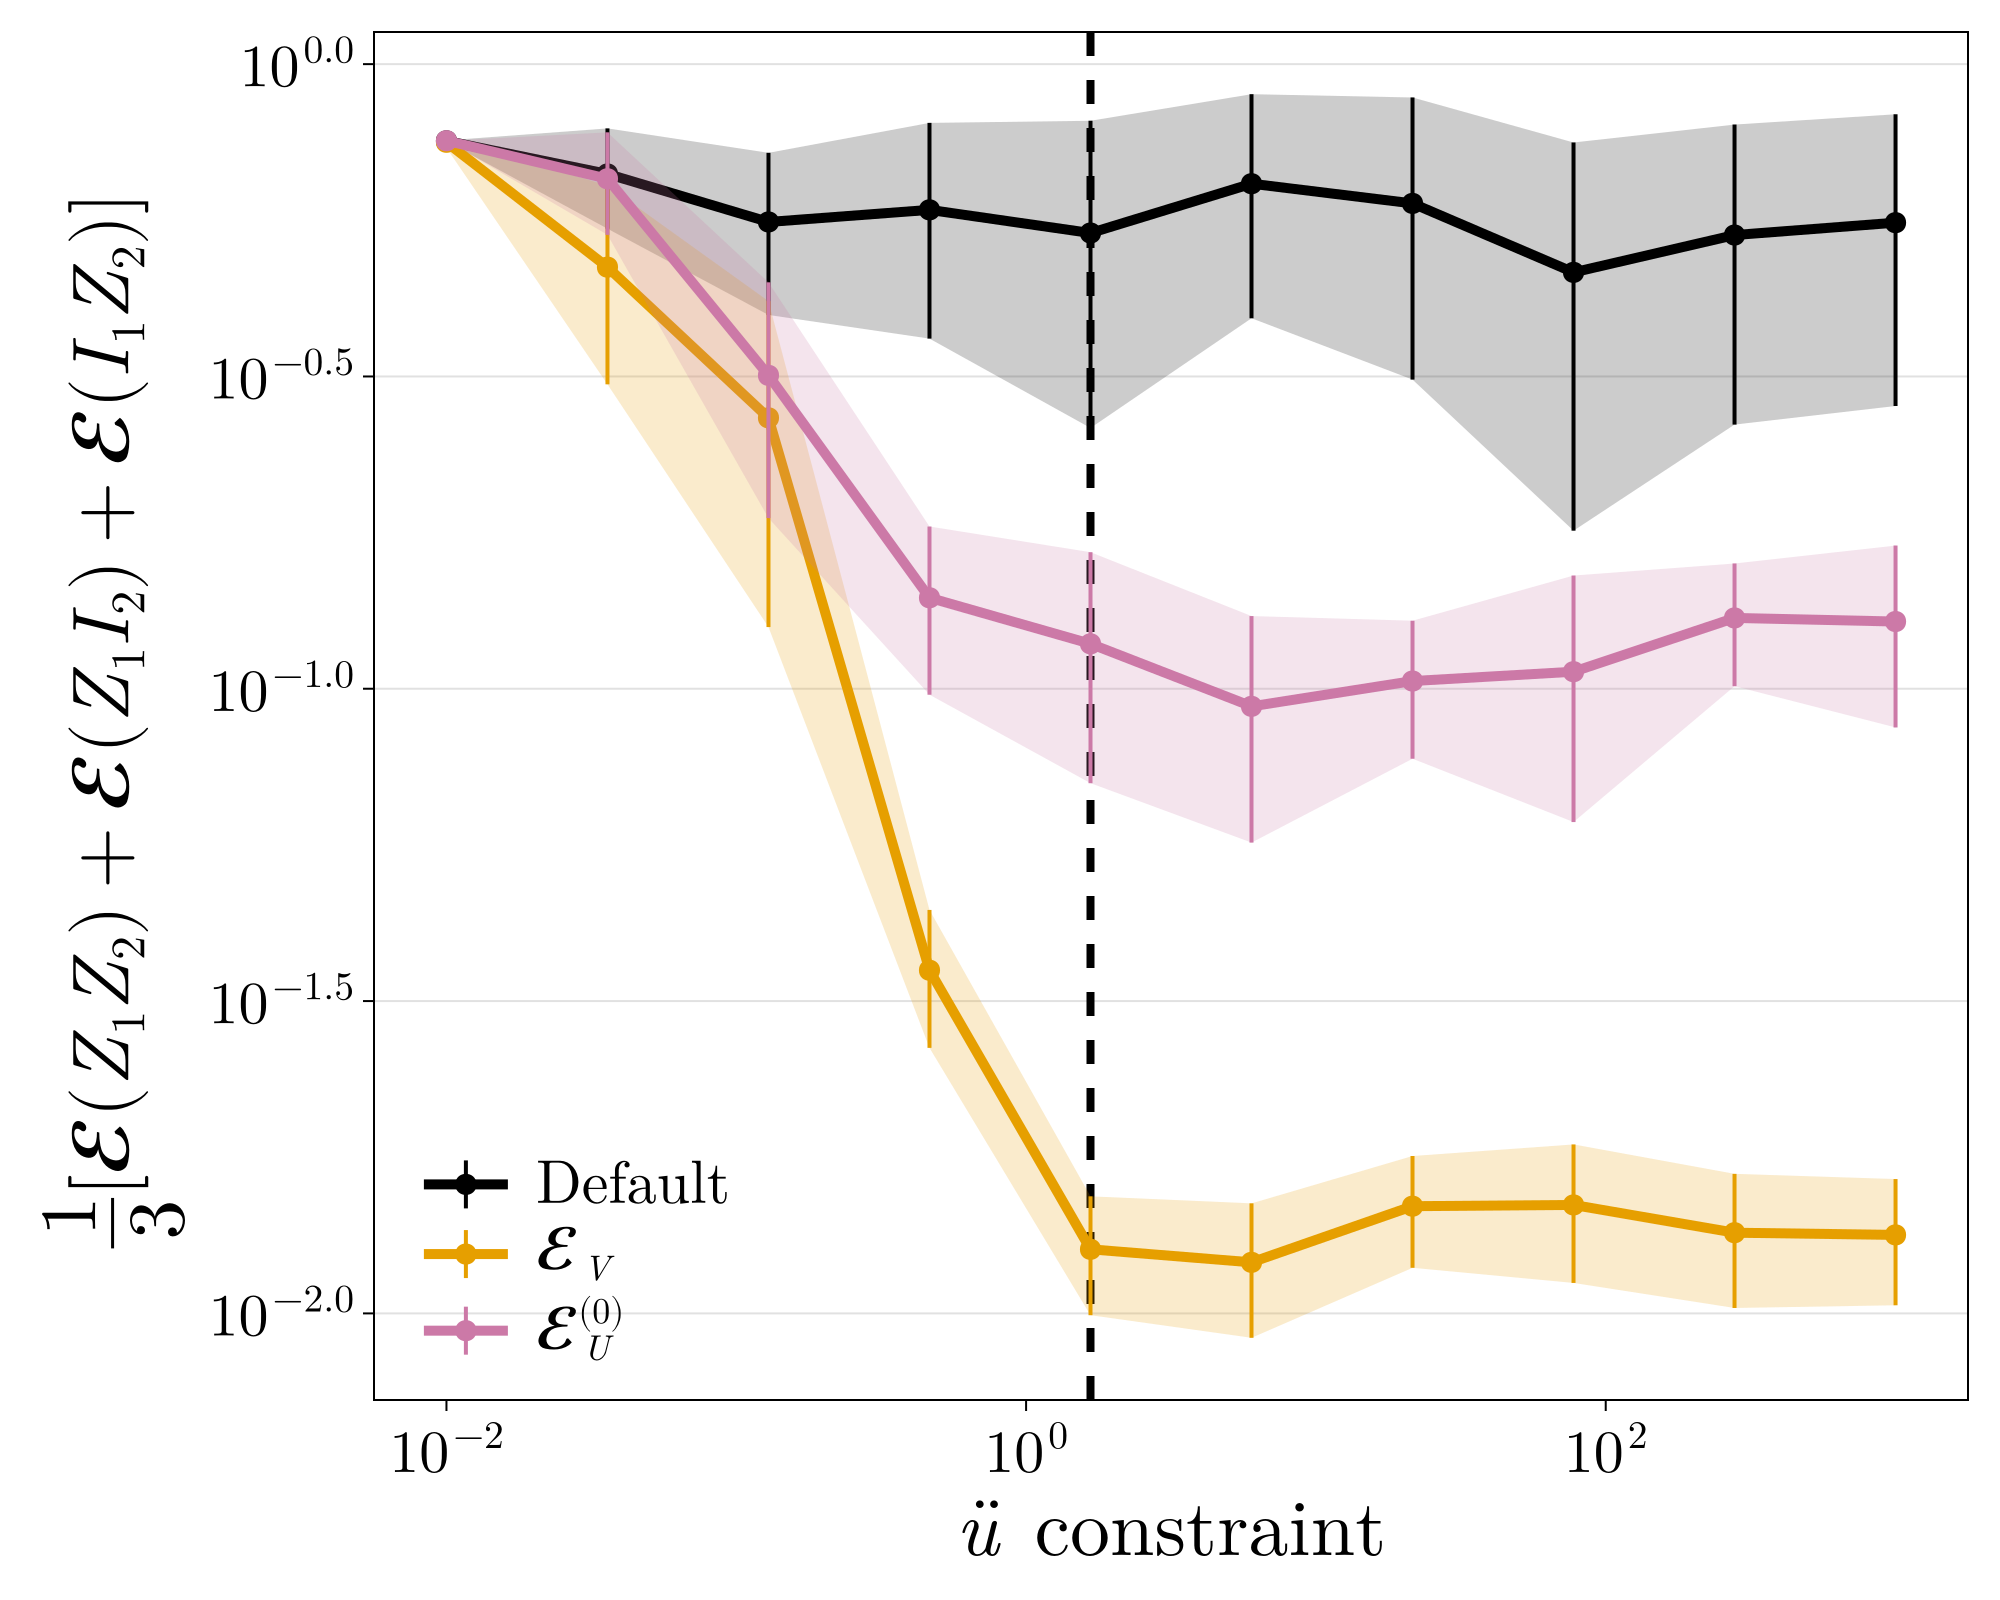

CairoMakie.Screen{IMAGE}


In [10]:
using Pkg
Pkg.activate("..")
using CairoMakie
using CSV
using DataFrames
using Statistics
using LaTeXStrings  # for proper LaTeX math in labels

# ============= PARAMETERS TO CHANGE =============
num_seeds = 50
index = 5  # which ä_vals index to highlight with a vertical line
# ================================================

function calculate_stats(data_list)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds  = [std(data_matrix[i, :])  for i in 1:n_points]
    return means, stds
end

function aggregate_seed_data_avg(num_seeds::Int)
    def_data = Vector{Vector{Float64}}()
    var_data = Vector{Vector{Float64}}()
    uni_data = Vector{Vector{Float64}}()
    ä_vals   = nothing

    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            @info "Missing $filename — skipping"
            continue
        end
        try
            df = CSV.read(filename, DataFrame)
            if ä_vals === nothing
                ä_vals = Vector{Float64}(df.ä_vals)
            end
            push!(def_data, Vector{Float64}(df.def_avg_vec))
            push!(var_data, Vector{Float64}(df.var_avg_vec))
            push!(uni_data, Vector{Float64}(df.uni_avg_vec))
        catch e
            @warn "Error reading $filename: $e"
            continue
        end
    end
    return def_data, var_data, uni_data, ä_vals
end

function scatter_with_line_and_error!(ax, x, y, yerr; color, label)
    band!(ax, x, y .- yerr, y .+ yerr; color=(color, 0.2))
    lines!(ax, x, y; color=color, linewidth=5)
    scatter!(ax, x, y; color=color, marker=:circle, markersize=15)
    errorbars!(ax, x, y, yerr; color=color, linewidth=2, whiskerwidth=0)
end

# ---- Read & aggregate
@info "Reading average data from $num_seeds seed files..."
def_data, var_data, uni_data, ä_vals = aggregate_seed_data_avg(num_seeds)
isempty(def_data) && error("No data found!")

# ---- Stats
@info "Computing statistics..."
def_means, def_stds = calculate_stats(def_data)
var_means, var_stds = calculate_stats(var_data)
uni_means, uni_stds = calculate_stats(uni_data)

# ---- Figure
fig = Figure(size=(1000, 800), fontsize=70)
ax  = Axis(fig[1, 1];
    xlabel = L"\ddot{u} \text{ constraint}",
    ylabel = L"\frac{1}{3}[\mathcal{E}(Z_1 Z_2)+\mathcal{E}(Z_1 I_2)+\mathcal{E}(I_1 Z_2)]",
    xscale = log10,
    yscale = log10,
    xlabelsize = 40,
    ylabelsize = 40,
    xticklabelsize = 30,
    yticklabelsize = 30,
)

colors = Makie.wong_colors()
colors[1] = RGBf(0, 0, 0) 
# Draw vertical line FIRST so it appears beneath the data
if 1 ≤ index ≤ length(ä_vals)
    vlines!(ax, ä_vals[index]; color=:black, linestyle=:dash, linewidth=4)
else
    @warn "index=$index out of bounds for ä_vals (length=$(length(ä_vals))) — skipping vline"
end

# Plot data (these render on top)
scatter_with_line_and_error!(ax, ä_vals, def_means, def_stds; color=colors[1], label="Default")
scatter_with_line_and_error!(ax, ä_vals, var_means, var_stds; color=colors[2], label="Variational")
scatter_with_line_and_error!(ax, ä_vals, uni_means, uni_stds; color=colors[4], label="Universal")

# --- Custom legend with centered vertical error bar + dot marker ---
legend_elements = [
    [
        LineElement(color=colors[1], linewidth=5,
                    points=[Point2f(0.15, 0.5), Point2f(0.85, 0.5)]),  # horizontal line
        LineElement(color=colors[1], linewidth=2,
                    points=[Point2f(0.5, 0.1), Point2f(0.5, 0.9)]),  # vertical error bar
        MarkerElement(color=colors[1], marker=:circle, markersize=15)  # centered dot
    ],
    [
        LineElement(color=colors[2], linewidth=5,
                    points=[Point2f(0.15, 0.5), Point2f(0.85, 0.5)]),
        LineElement(color=colors[2], linewidth=2,
                    points=[Point2f(0.5, 0.1), Point2f(0.5, 0.9)]),
        MarkerElement(color=colors[2], marker=:circle, markersize=15)
    ],
    [
        LineElement(color=colors[4], linewidth=5,
                    points=[Point2f(0.15, 0.5), Point2f(0.85, 0.5)]),
        LineElement(color=colors[4], linewidth=2,
                    points=[Point2f(0.5, 0.1), Point2f(0.5, 0.9)]),
        MarkerElement(color=colors[4], marker=:circle, markersize=15)
    ]
]

Legend(fig[1, 1],
    legend_elements,
    ["Default", L"\mathcal{E}_V", L"\mathcal{E}_U^{(0)}"],
    halign = :left,
    valign = :bottom,
    tellheight = false,
    tellwidth = false,
    margin = (10, 10, 10, 10),
    framevisible = false,
    labelsize = 30,
    patchsize = (60, 30)
)

save("dda_constraint_iswap_paper_fig.svg", fig; px_per_unit=2)
display(fig)

In [11]:
Pkg.add("LaTeXStrings")

   Resolving package versions...
  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651


┌ Info: Reading full data for bar chart (index=5)…
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sdnNjb2RlLXJlbW90ZQ==.jl:63
┌ Info: Missing dda_constraint_iswap_T50_seed_14.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constraint_iswap_T50_seed_15.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constraint_iswap_T50_seed_16.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constraint_iswap_T50_seed_17.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constrai

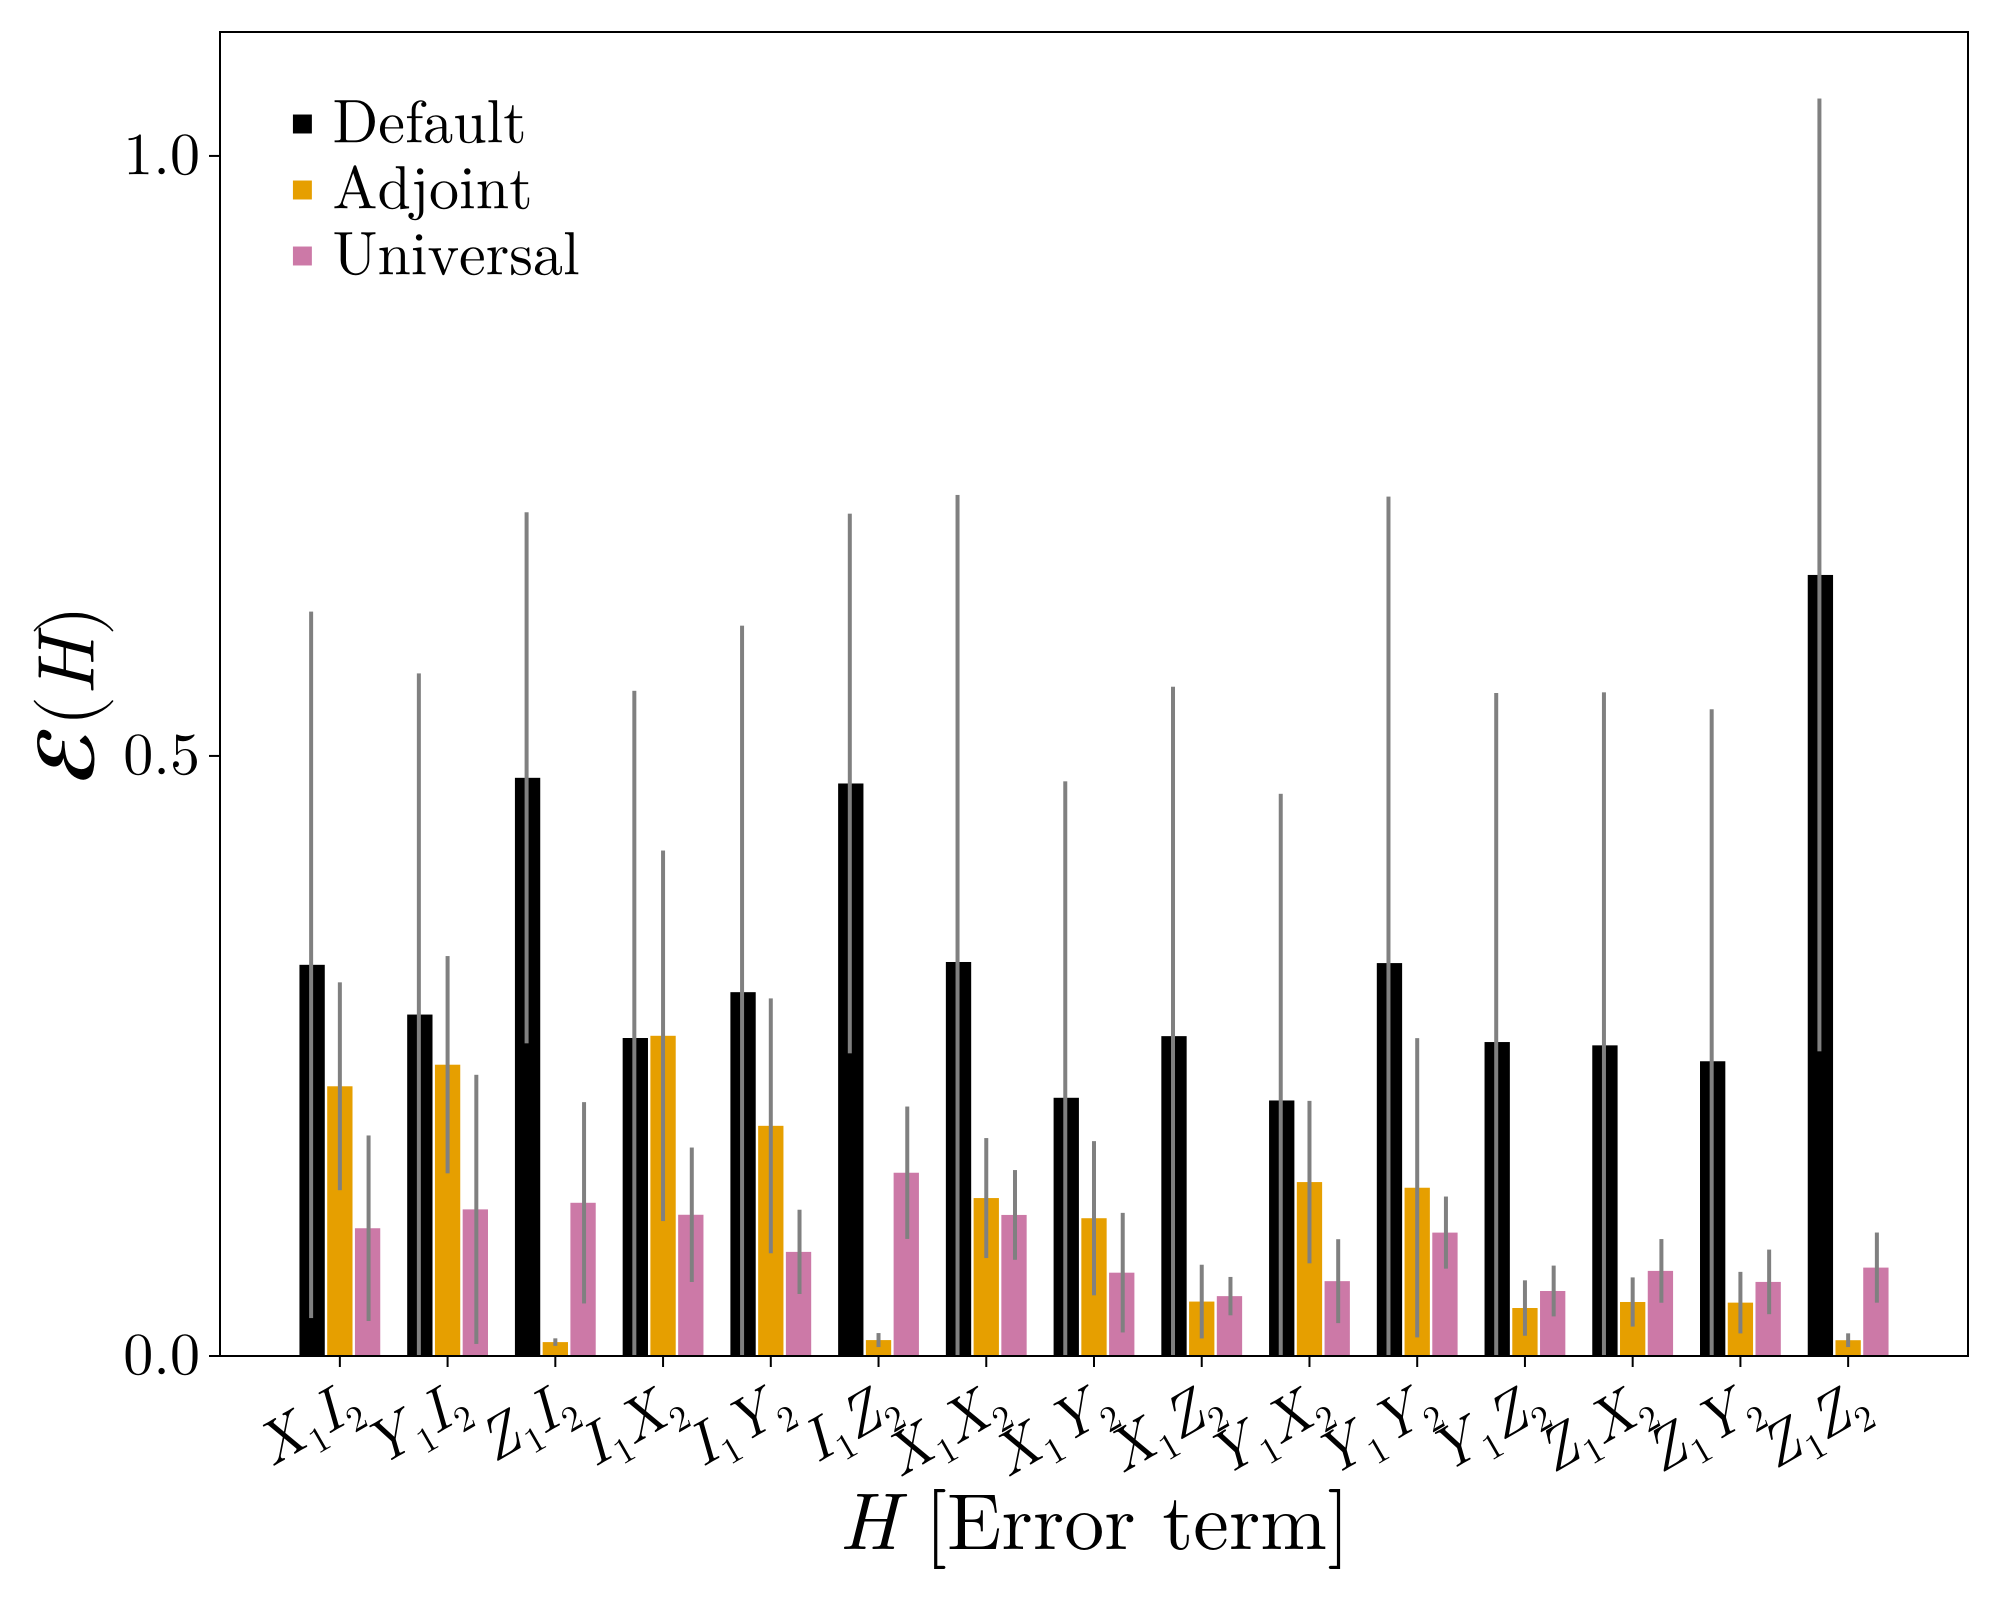

In [12]:
using CairoMakie
using CSV
using DataFrames
using Statistics

# ============= PARAMETERS TO CHANGE =============
num_seeds = 50
index = 5  # which ä_vals row to use for per-term bar chart
outfile = "iswap_pauli_susceptibility_bars.png"
# ================================================

function parse_vector_string(s::String)
    s = strip(s)
    s = replace(s, r"^Any" => "")
    s = replace(s, "[" => "")
    s = replace(s, "]" => "")
    parts = filter(!isempty, strip.(split(s, ",")))
    return parse.(Float64, parts)
end

function calculate_stats(data_list)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds  = [std(data_matrix[i, :])  for i in 1:n_points]
    return means, stds
end

function aggregate_seed_data_full(num_seeds::Int, index::Int)
    var_data = Vector{Vector{Float64}}()
    def_data = Vector{Vector{Float64}}()
    uni_data = Vector{Vector{Float64}}()
    ä_val = nothing

    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            @info "Missing $filename — skipping"
            continue
        end
        try
            df = CSV.read(filename, DataFrame)
            if ä_val === nothing
                @assert 1 ≤ index ≤ nrow(df) "index=$index out of bounds for file $filename"
                ä_val = df.ä_vals[index]
            end
            var_full = parse_vector_string(df.var_full_vec[index])
            def_full = parse_vector_string(df.def_full_vec[index])
            uni_full = parse_vector_string(df.uni_full_vec[index])

            push!(var_data, var_full)
            push!(def_data, def_full)
            push!(uni_data, uni_full)
        catch e
            @warn "Error reading $filename: $e"
            continue
        end
    end
    return var_data, def_data, uni_data, ä_val
end

# ---- Read & aggregate
@info "Reading full data for bar chart (index=$index)…"
var_data_full, def_data_full, uni_data_full, ä_val = aggregate_seed_data_full(num_seeds, index)
isempty(var_data_full) && error("No data found!")

# ---- Stats
@info "Computing statistics…"
var_means_full, var_stds_full = calculate_stats(var_data_full)
def_means_full, def_stds_full = calculate_stats(def_data_full)
uni_means_full, uni_stds_full = calculate_stats(uni_data_full)

# ---- Labels & layout
err_labels = [L"X_1 I_2", L"Y_1 I_2", L"Z_1 I_2", L"I_1 X_2", L"I_1 Y_2", L"I_1 Z_2",
              L"X_1 X_2", L"X_1 Y_2", L"X_1 Z_2", L"Y_1 X_2", L"Y_1 Y_2", L"Y_1 Z_2", L"Z_1 X_2", L"Z_1 Y_2", L"Z_1 Z_2"]
n_errors = length(err_labels)
@assert length(def_means_full) == n_errors "Expected $n_errors terms; got $(length(def_means_full))"

y    = collect(Iterators.flatten((def_means_full[i], var_means_full[i], uni_means_full[i]) for i in 1:n_errors))
yerr = collect(Iterators.flatten((def_stds_full[i],  var_stds_full[i],  uni_stds_full[i])  for i in 1:n_errors))

x = repeat(1:n_errors, inner=3)     # category positions
g = repeat(1:3, outer=n_errors)     # group ids inside each category (1:Default, 2:Variational, 3:Universal)

colors = Makie.wong_colors()
colors[1] = RGBf(0, 0, 0) 
series_colors = [colors[1], colors[2], colors[4]]
barcolors = series_colors[g]

# ---- Figure
fig = Figure(size=(1000, 800), fontsize=60)
ax  = Axis(fig[1, 1];
    xticks = (1:n_errors, err_labels),
    xticklabelrotation = π/6,
    xlabel = L"H \text{ [Error term]}",
    ylabel = L"\mathcal{E}(H)",
    xlabelsize = 40,
    ylabelsize = 40,
    xticklabelsize = 30,
    yticklabelsize = 30,
    limits = (nothing, nothing, 0, nothing), 
    xgridvisible = false,  
    ygridvisible = false, 
)

barplot!(ax, x, y; dodge=g, color=barcolors, gap=0.25)

# Error bars aligned to dodged bars
dodge_width = 0.8
n_dodge = 3
width = dodge_width / n_dodge
error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in eachindex(x)]
errorbars!(ax, error_x, y, yerr; color=:gray, linewidth=2)

# Legend (use invisible scatters to show colors with square markers)
scatter!(ax, [NaN], [NaN]; color=series_colors[1], marker=:rect, markersize=15, label="Default")
scatter!(ax, [NaN], [NaN]; color=series_colors[2], marker=:rect, markersize=15, label="Adjoint")
scatter!(ax, [NaN], [NaN]; color=series_colors[3], marker=:rect, markersize=15, label="Universal")
axislegend(ax; position=:rt, labelsize=30, framevisible = false, margin = (25, 25, 25, 25), halign = :left, valign = :top,)

display(fig)
save(outfile, fig; px_per_unit=2)

@info "Figure saved: $outfile"
@info "Parameters: num_seeds=$num_seeds, index=$index (ä=$(round(ä_val, sigdigits=3)))"


┌ Info: Reading full data for bar chart (index=5)…
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sdnNjb2RlLXJlbW90ZQ==.jl:63
┌ Info: Missing dda_constraint_iswap_T50_seed_14.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constraint_iswap_T50_seed_15.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constraint_iswap_T50_seed_16.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constraint_iswap_T50_seed_17.csv — skipping
└ @ Main /home/atkamen/notebooks/src/iswap_sweep_v2/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sdnNjb2RlLXJlbW90ZQ==.jl:38
┌ Info: Missing dda_constrai

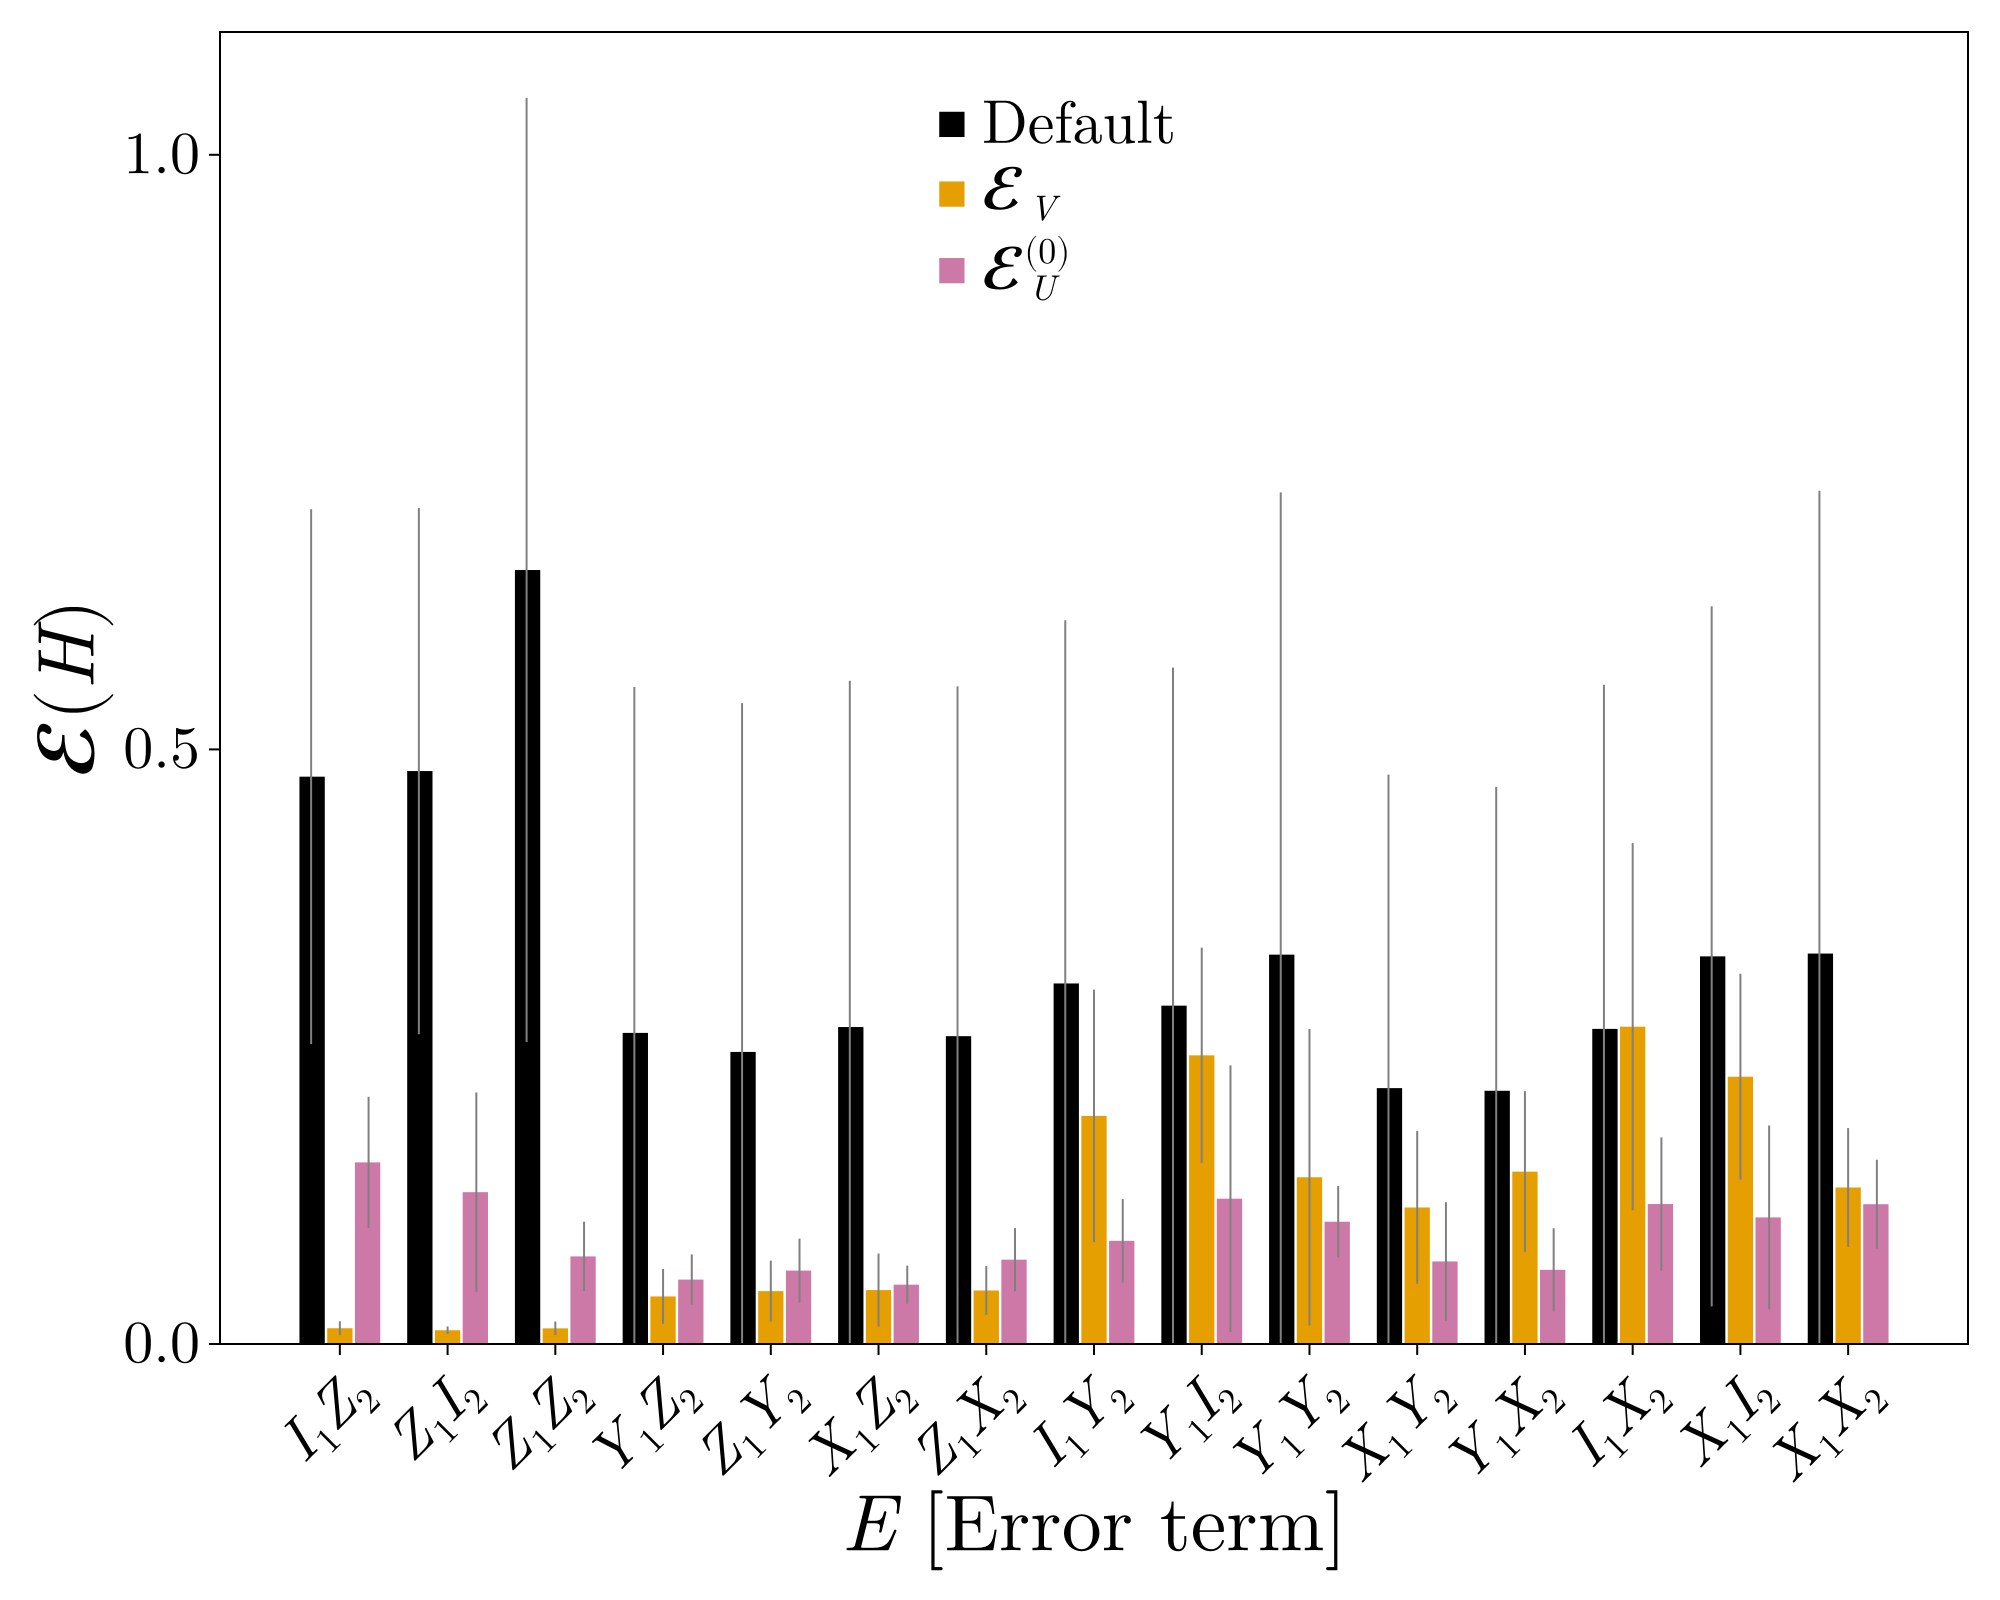

In [13]:
using CairoMakie
using CSV
using DataFrames
using Statistics

# ============= PARAMETERS TO CHANGE =============
num_seeds = 50
index = 5  # which ä_vals row to use for per-term bar chart
outfile = "iswap_pauli_susceptibility_bars.svg"
# ================================================

function parse_vector_string(s::String)
    s = strip(s)
    s = replace(s, r"^\s*Any" => "")
    s = replace(s, "[" => "")
    s = replace(s, "]" => "")
    parts = filter(!isempty, strip.(split(s, ",")))
    return parse.(Float64, parts)
end

function calculate_stats(data_list)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds  = [std(data_matrix[i, :])  for i in 1:n_points]
    return means, stds
end

function aggregate_seed_data_full(num_seeds::Int, index::Int)
    var_data = Vector{Vector{Float64}}()
    def_data = Vector{Vector{Float64}}()
    uni_data = Vector{Vector{Float64}}()
    ä_val = nothing

    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            @info "Missing $filename — skipping"
            continue
        end
        try
            df = CSV.read(filename, DataFrame)
            if ä_val === nothing
                @assert 1 ≤ index ≤ nrow(df) "index=$index out of bounds for file $filename"
                ä_val = df.ä_vals[index]
            end
            var_full = parse_vector_string(df.var_full_vec[index])
            def_full = parse_vector_string(df.def_full_vec[index])
            uni_full = parse_vector_string(df.uni_full_vec[index])

            push!(var_data, var_full)
            push!(def_data, def_full)
            push!(uni_data, uni_full)
        catch e
            @warn "Error reading $filename: $e"
            continue
        end
    end
    return var_data, def_data, uni_data, ä_val
end

# ---- Read & aggregate
@info "Reading full data for bar chart (index=$index)…"
var_data_full, def_data_full, uni_data_full, ä_val = aggregate_seed_data_full(num_seeds, index)
isempty(var_data_full) && error("No data found!")

# ---- Stats
@info "Computing statistics…"
var_means_full, var_stds_full = calculate_stats(var_data_full)
def_means_full, def_stds_full = calculate_stats(def_data_full)
uni_means_full, uni_stds_full = calculate_stats(uni_data_full)

# ---- Labels (original order in your files)
err_labels = [
    L"X_1 I_2", L"Y_1 I_2", L"Z_1 I_2",
    L"I_1 X_2", L"I_1 Y_2", L"I_1 Z_2",
    L"X_1 X_2", L"X_1 Y_2", L"X_1 Z_2",
    L"Y_1 X_2", L"Y_1 Y_2", L"Y_1 Z_2",
    L"Z_1 X_2", L"Z_1 Y_2", L"Z_1 Z_2"
]
n_errors = length(err_labels)
@assert length(def_means_full) == n_errors "Expected $n_errors terms; got $(length(def_means_full))"

# ---- Reorder to: XX, XI, IX, YX, XY, YY, YI, IY, ZX, XZ, ZY, YZ, ZZ, ZI, IZ
# Mapping to indices in the original err_labels:
# XX→7, XI→1, IX→4, YX→10, XY→8, YY→11, YI→2, IY→5, ZX→13, XZ→9, ZY→14, YZ→12, ZZ→15, ZI→3, IZ→6
perm = reverse([7, 1, 4, 10, 8, 11, 2, 5, 13, 9, 14, 12, 15, 3, 6])

err_labels     = err_labels[perm]
def_means_full = def_means_full[perm]
var_means_full = var_means_full[perm]
uni_means_full = uni_means_full[perm]
def_stds_full  = def_stds_full[perm]
var_stds_full  = var_stds_full[perm]
uni_stds_full  = uni_stds_full[perm]

n_errors = length(err_labels)  # still 15

# ---- Flatten data for dodged bars
y    = collect(Iterators.flatten((def_means_full[i], var_means_full[i], uni_means_full[i]) for i in 1:n_errors))
yerr = collect(Iterators.flatten((def_stds_full[i],  var_stds_full[i],  uni_stds_full[i])  for i in 1:n_errors))

x = repeat(1:n_errors, inner=3)     # category positions
g = repeat(1:3, outer=n_errors)     # 1:Default, 2:Adjoint (Variational), 3:Universal

colors = Makie.wong_colors()
colors[1] = RGBf(0, 0, 0) 
series_colors = [colors[1], colors[2], colors[4]]
barcolors = series_colors[g]

# ---- Figure
fig = Figure(size=(1000, 800), fontsize=20)
ax  = Axis(fig[1, 1];
    xticks = (1:n_errors, err_labels),
    xticklabelrotation = π/4,
    xlabel = L"E \text{ [Error term]}",
    ylabel = L"\mathcal{E}(H)",
    xlabelsize = 40,
    ylabelsize = 40,
    xticklabelsize = 30,
    yticklabelsize = 30,
    limits = (nothing, nothing, 0, nothing),
    xgridvisible = false,
    ygridvisible = false,
)

barplot!(ax, x, y; dodge=g, color=barcolors, gap=0.25)

# Error bars aligned to dodged bars
dodge_width = 0.8
n_dodge = 3
width = dodge_width / n_dodge
error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in eachindex(x)]
errorbars!(ax, error_x, y, yerr; color=:gray, linewidth=1)

# Legend (use invisible scatters to show colors with square markers)
scatter!(ax, [NaN], [NaN]; color=series_colors[1], marker=:rect, markersize=20, label="Default")
scatter!(ax, [NaN], [NaN]; color=series_colors[2], marker=:rect, markersize=20, label=L"\mathcal{E}_V")
scatter!(ax, [NaN], [NaN]; color=series_colors[3], marker=:rect, markersize=20, label=L"\mathcal{E}_U^{(0)}")
axislegend(ax; position=:rt, labelsize=30, framevisible=false, margin=(350, 25, 25, 25), halign=:left, valign=:top)

display(fig)
save(outfile, fig; px_per_unit=2)

@info "Parameters: num_seeds=$num_seeds, index=$index (ä=$(round(ä_val, sigdigits=3)))"

In [14]:
using CairoMakie
using CSV
using DataFrames
using Statistics

# ============= PARAMETERS TO CHANGE =============
num_seeds = 44
index = 7  # Which ä_vals index for bar chart
# ================================================

function parse_vector_string(s::String)
    s = strip(s)
    s = replace(s, r"^Any" => "")
    s = replace(s, "[" => "")
    s = replace(s, "]" => "")
    parts = filter(!isempty, strip.(split(s, ",")))
    return parse.(Float64, parts)
end

function scatter_with_line_and_error!(ax, x, y, yerr; color, label)
    band!(ax, x, y .- yerr, y .+ yerr; color=(color, 0.2))
    lines!(ax, x, y; color=color, linewidth=3)
    scatter!(ax, x, y; color=color, marker=:circle, markersize=10, label=label)
    errorbars!(ax, x, y, yerr; color=color, linewidth=2, whiskerwidth=8)
end

function aggregate_seed_data_avg(num_seeds::Int)
    def_data = []
    var_data = []
    uni_data = []
    ä_vals = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            if ä_vals === nothing
                ä_vals = df.ä_vals
            end
            push!(def_data, df.def_avg_vec)
            push!(var_data, df.var_avg_vec)
            push!(uni_data, df.uni_avg_vec)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return def_data, var_data, uni_data, ä_vals
end

function aggregate_seed_data_full(num_seeds::Int, index::Int)
    var_data = []
    def_data = []
    uni_data = []
    ä_val = nothing
    
    for seed in 1:num_seeds
        filename = "dda_constraint_iswap_T50_seed_$seed.csv"
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        
        try
            df = CSV.read(filename, DataFrame)
            if ä_val === nothing
                ä_val = df.ä_vals[index]
            end
            var_full = parse_vector_string(df.var_full_vec[index])
            def_full = parse_vector_string(df.def_full_vec[index])
            uni_full = parse_vector_string(df.uni_full_vec[index])
            
            push!(var_data, var_full)
            push!(def_data, def_full)
            push!(uni_data, uni_full)
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    
    return var_data, def_data, uni_data, ä_val
end

function calculate_stats(data_list)
    data_matrix = hcat(data_list...)
    n_points = size(data_matrix, 1)
    means = [mean(data_matrix[i, :]) for i in 1:n_points]
    stds = [std(data_matrix[i, :]) for i in 1:n_points]
    return means, stds
end

# Read data for both plots
println("Reading average data from $num_seeds seed files...")
def_data, var_data, uni_data, ä_vals = aggregate_seed_data_avg(num_seeds)

if isempty(def_data)
    error("No data found!")
end

println("Calculating statistics for average plot...")
def_means, def_stds = calculate_stats(def_data)
var_means, var_stds = calculate_stats(var_data)
uni_means, uni_stds = calculate_stats(uni_data)

println("Reading full data for bar chart (index=$index)...")
var_data_full, def_data_full, uni_data_full, ä_val = aggregate_seed_data_full(num_seeds, index)

println("Calculating statistics for bar chart...")
var_means_full, var_stds_full = calculate_stats(var_data_full)
def_means_full, def_stds_full = calculate_stats(def_data_full)
uni_means_full, uni_stds_full = calculate_stats(uni_data_full)

# Create figure with two subplots
fig = Figure(size=(1800, 800), fontsize=24)

# Colors
colors = Makie.wong_colors()
series_colors = [colors[1], colors[2], colors[4]]

# LEFT PLOT: Line plot with error bars
ax1 = Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)",
    xscale = log10,
    yscale = log10,
    title = "Dephasing robustness vs control acceleration",
    xlabelsize = 32,
    ylabelsize = 32,
    titlesize = 36,
    xticklabelsize = 28,
    yticklabelsize = 28,
)

scatter_with_line_and_error!(ax1, ä_vals, def_means, def_stds; color=colors[1], label="Default")
scatter_with_line_and_error!(ax1, ä_vals, var_means, var_stds; color=colors[2], label="Variational")
scatter_with_line_and_error!(ax1, ä_vals, uni_means, uni_stds; color=colors[4], label="Universal")

vlines!(ax1, ä_vals[index]; color=:red, linestyle=:dash, linewidth=3)

axislegend(ax1; position=:rt, labelsize=28)

# RIGHT PLOT: Bar chart
err_labels = ["X₁", "Y₁", "Z₁", "X₂", "Y₂", "Z₂", "XX", "XY", "XZ", "YX", "YY", "YZ", "ZX", "ZY", "ZZ"]
n_errors = length(err_labels)

y = collect(Iterators.flatten((def_means_full[i], var_means_full[i], uni_means_full[i]) for i in 1:n_errors))
yerr = collect(Iterators.flatten((def_stds_full[i], var_stds_full[i], uni_stds_full[i]) for i in 1:n_errors))

x = repeat(1:n_errors, inner=3)
g = repeat(1:3, outer=n_errors)
barcolors = series_colors[g]

ax2 = Axis(fig[1, 2];
    xticks = (1:n_errors, err_labels),
    xticklabelrotation = π/6,
    xlabel = "H (error term)",
    ylabel = "Ɛ(H)",
    title = "Susceptibility to Pauli errors (ä = $(round(ä_val, sigdigits=3)))",
    xlabelsize = 32,
    ylabelsize = 32,
    titlesize = 36,
    xticklabelsize = 28,
    yticklabelsize = 28,
)

barplot!(ax2, x, y; dodge=g, color=barcolors, gap=0.25)

dodge_width = 0.8
n_dodge = 3
width = dodge_width / n_dodge
error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in 1:length(x)]
errorbars!(ax2, error_x, y, yerr; color=:gray, linewidth=2)

axislegend(ax2; position=:rt, labelsize=28)

# Add panel labels
Label(fig[1, 1, TopLeft()], "(a)", fontsize=42, padding=(15, 0, 15, 0), tellwidth=false, tellheight=false)
Label(fig[1, 2, TopLeft()], "(b)", fontsize=42, padding=(15, 0, 15, 0), tellwidth=false, tellheight=false)

display(fig)
save("combined_iswap_figure_$(num_seeds)seeds.png", fig; px_per_unit=2)

println("\nFigure saved: combined_iswap_figure_$(num_seeds)seeds.png")
println("Parameters used: num_seeds=$num_seeds, index=$index (ä=$(round(ä_val, sigdigits=3)))")

Reading average data from 44 seed files...
Calculating statistics for average plot...
Reading full data for bar chart (index=7)...
Calculating statistics for bar chart...


ErrorException: There are no plots with labels in the given axis that can be put in the legend. Supply labels to plotting functions like `plot(args...; label = "My label")`

In [15]:
using Pkg
Pkg.activate("..")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:8
dfs = DataFrame[]
for i in seed_range
    fn = "dda_dephasing_study/acceleration_sweep_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)

  Activating project at `~/notebooks/src`


ErrorException: cannot declare Main.CM constant; it already has a value

In [16]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:8
dfs = DataFrame[]
for i in seed_range
    fn = "dda_dephasing_study/acceleration_sweep_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:var_obj_def_z)
Y_var = stackcol(:var_obj_var_z)
Y_add = stackcol(:var_obj_tog_z)
Y_uni = stackcol(:var_obj_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)

  Activating project at `~/notebooks/src/iswap_sweep_v2`


ArgumentError: ArgumentError: Package DataFrames not found in current path, maybe you meant `import/using .DataFrames`.
- Otherwise, run `import Pkg; Pkg.add("DataFrames")` to install the DataFrames package.